# Trabalho Prático 1 
#### Leonardo Demore - 15674786
#### Arthur Araujo - 14651458

# Carregamento dos dados

In [1]:
import ir_datasets
import pandas as pd
from pathlib import Path

dataset = ir_datasets.load("cranfield")

docs = pd.DataFrame(
    dataset.docs_iter(),
    columns=["doc_id", "title", "text", "author", "bib"]
)

docs.head()

,doc_id,title,text,author,bib
0,1,experimental investigation of the aerodynamics...,experimental investigation of the aerodynamics...,"brenckman,m.","j. ae. scs. 25, 1958, 324."
1,2,simple shear flow past a flat plate in an inco...,simple shear flow past a flat plate in an inco...,ting-yili,"department of aeronautical engineering, rensse..."
2,3,the boundary layer in simple shear flow past a...,the boundary layer in simple shear flow past a...,m. b. glauert,"department of mathematics, university of manch..."
3,4,approximate solutions of the incompressible la...,approximate solutions of the incompressible la...,"yen,k.t.","j. ae. scs. 22, 1955, 728."
4,5,one-dimensional transient heat conduction into...,one-dimensional transient heat conduction into...,"wasserman,b.","j. ae. scs. 24, 1957, 924."


In [2]:
queries = pd.DataFrame(
    dataset.queries_iter(),
    columns=["query_id", "text"]
)

queries.head()

,query_id,text
0,1,what similarity laws must be obeyed when const...
1,2,what are the structural and aeroelastic proble...
2,3,what problems of heat conduction in composite ...
3,4,can a criterion be developed to show empirical...
4,5,what chemical kinetic system is applicable to ...


In [3]:
qrels = pd.DataFrame(
    dataset.qrels_iter(),
    columns=["query_id", "doc_id", "relevance", "iteration"]
)

qrels.head()

,query_id,doc_id,relevance,iteration
0,1,184,2,0
1,1,29,2,0
2,1,31,2,0
3,1,12,3,0
4,1,51,3,0


In [4]:
Path("data").mkdir(parents=True, exist_ok=True)

docs.to_csv("data/cranfield_docs.csv", index=False)
queries.to_csv("data/cranfield_queries.csv", index=False)
qrels.to_csv("data/cranfield_qrels.csv", index=False)

# Pré-processamento - Requisito 1


## Decisões de projeto

**Campos indexados.** Seguindo a convenção para esta coleção, indexamos **apenas `text`**: `author` e `bib` são metadados bibliográficos (nomes próprios, nomes de revistas, volumes, anos) que não descrevem o assunto do documento e só introduziriam ruído no casamento com as consultas.

**Tokenização por regex.** Usamos `re.findall(r"[a-z0-9]+", texto)`
em vez do `word_tokenize` do NLTK. A Cranfield é texto científico em inglês onde a pontuação é sempre separada por espaço (`slipstream .`).
A regex resolve normalização e tokenização em uma única passada. Mantemos dígitos porque em alguns documentos eles carregam sentido.

**Normalização para minúsculas.** Aplicada sempre em documentos e consultas, de modo que `Boundary` e `boundary` sejam o mesmo termo. Essa é a única normalização presente na configuração baseline.

**Stemming de Porter.** Reduz variantes morfológicas ao mesmo radical (ex: `aerodynamics` → `aerodynam`), aumentando o *recall*. Usamos o `PorterStemmer` do NLTK, permitido pela especificação.


### As quatro configurações comparadas

Conforme exigido pelo enunciado, avaliamos estas quatro combinações:

| Configuração | Stopwords | Stemming |
|---|---|---|
| `nada` | — | — |
| `stopwords` | removidas | — |
| `stemming` | — | Porter |
| `stopwords+stemming` | removidas | Porter |

### Leitura dos dados

In [5]:
import re
import time
import pandas as pd
from nltk.corpus import stopwords
from collections import Counter
from nltk.stem import PorterStemmer

DATA_DIR = "data"

# dtype=str nos identificadores para que doc_id/query_id casem entre os três
# arquivos sem depender do pandas. fillna("") porque dois
# documentos da coleção têm o campo de texto vazio.
docs = pd.read_csv(f"{DATA_DIR}/cranfield_docs.csv", dtype={"doc_id": str}).fillna("")
queries = pd.read_csv(f"{DATA_DIR}/cranfield_queries.csv", dtype={"query_id": str}).fillna("")
qrels = pd.read_csv(
    f"{DATA_DIR}/cranfield_qrels.csv", dtype={"query_id": str, "doc_id": str}
)

print(f"documentos: {len(docs)}")
print(f"consultas:  {len(queries)}")
print(f"qrels:      {len(qrels)}")

documentos: 1400
consultas:  225
qrels:      1837


### Função de pré-processamento

O pipeline é uma função única, `preprocess`, controlada por dois parâmetros
booleanos. Isso deixa as configurações do enunciado como quatro chamadas da mesma função.

O stemming é uma etapa cara, então os resultados são salvos em um
dicionário: cada termo distinto do vocabulário é reduzido uma única vez, embora
apareça muitas vezes na coleção.

In [6]:
TOKEN_RE = re.compile(r"[a-z0-9]+")
STOPWORDS = frozenset(stopwords.words("english"))
_stemmer = PorterStemmer()
_stem_cache = {}


def tokenize(text):
    """Normaliza para minúsculas e extrai sequências de letras e números"""
    return TOKEN_RE.findall(text.lower())


def stem(token):
    """Radical de Porter, com memoização por termo."""
    radical = _stem_cache.get(token)
    if radical is None:
        radical = _stemmer.stem(token)
        _stem_cache[token] = radical
    return radical


def preprocess(text, remove_stopwords=False, apply_stemming=False):
    """ 
    Ordem sempre fixa: tokenização, remoção de stopwords e por último stemming.
    É possível modificar a função pelos parâmetros booleanos.
    """
    tokens = tokenize(text)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS]
    if apply_stemming:
        tokens = [stem(t) for t in tokens]
    return tokens


print(f"stopwords do NLTK (inglês): {len(STOPWORDS)} termos")
print(f"amostra: {sorted(STOPWORDS)[:5]}")

stopwords do NLTK (inglês): 198 termos
amostra: ['a', 'about', 'above', 'after', 'again']


### Aplicação das quatro configurações

Guardamos o resultado em dois dicionários indexados pelo nome da configuração:
`doc_tokens[config]` e `query_tokens[config]` são listas de listas de termos, na
mesma ordem de `docs` e `queries`. Toda a coleção pré-processada cabe em memória com certa tranquilidade.

In [7]:
CONFIGS = {
    "nada": dict(remove_stopwords=False, apply_stemming=False),
    "stopwords": dict(remove_stopwords=True, apply_stemming=False),
    "stemming": dict(remove_stopwords=False, apply_stemming=True),
    "stopwords+stemming": dict(remove_stopwords=True, apply_stemming=True),
}

doc_tokens = {}
query_tokens = {}

for name, options in CONFIGS.items():
    doc_tokens[name] = [preprocess(t, **options) for t in docs["text"]]
    query_tokens[name] = [preprocess(t, **options) for t in queries["text"]]

# Índices auxiliares: posição na lista <-> identificador da coleção.
doc_ids = docs["doc_id"].tolist()
query_ids = queries["query_id"].tolist()

In [8]:
lines = []
for name in CONFIGS:
    vocabulary = set()
    terms_count = 0
    for terms in doc_tokens[name]:
        vocabulary.update(terms)
        terms_count += len(terms)
    query_count = sum(len(t) for t in query_tokens[name])

    lines.append(
        {
            "configuração": name,
            "vocabulário": len(vocabulary),
            "termos (total)": terms_count,
            "termos/doc": round(terms_count / len(docs), 1),
            "termos/consulta": round(query_count / len(queries), 1),
        }
    )

stats = pd.DataFrame(lines)
stats

,configuração,vocabulário,termos (total),termos/doc,termos/consulta
0,nada,7471,226526,161.8,17.4
1,stopwords,7352,132721,94.8,10.3
2,stemming,4820,226526,161.8,17.4
3,stopwords+stemming,4709,132721,94.8,10.3


### Efeito de cada configuração sobre a coleção

A tabela acima responde o requisito 1. Ela mede o que cada etapa faz, antes de qualquer recuperação.

As duas etapas atuam em **eixos diferentes**:

- **Remover stopwords** corta cerca de 41% do total de termos (226.526 → 132.721)
  mas apenas 119 entradas do vocabulário (7.471 → 7.352). São pouquíssimas
  palavras distintas, repetidas muitas vezes. O maior ganho é de **eficiência** (índice menor, menos posições a percorrer) e de redução de ruído na similaridade.

- **O stemming** não muda o total de termos (cada token continua
  existindo, mas com outra grafia), e reduz o vocabulário em 35% (7.471 →
  4.820), pois funde variantes da mesma palavra em um único termo. O ganho esperado
  é de **recall**.

Combinadas, as duas etapas produzem o vocabulário mais enxuto (4.709 termos) com
o menor número de termos indexados. Vale notar que a redução de vocabulário do
stemming é quase idêntica com e sem stopwords (35% contra 36%): as stopwords
contribuíam pouco para o vocabulário, então há pouca sobreposição entre o que
cada etapa elimina (as etapas são complementares).

### Resultado das configurações em um documento e uma consulta

In [9]:
print("DOCUMENTO 1 — primeiros 12 termos\n")
for name in CONFIGS:
    print(f"  {name:20s} {doc_tokens[name][0][:12]}")

print(f"\n\nCONSULTA 1 — {queries['text'][0].strip()!r}\n")
for name in CONFIGS:
    print(f"  {name:20s} {query_tokens[name][0]}")

DOCUMENTO 1 — primeiros 12 termos

  nada                 ['experimental', 'investigation', 'of', 'the', 'aerodynamics', 'of', 'a', 'wing', 'in', 'a', 'slipstream', 'an']
  stopwords            ['experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'study', 'wing', 'propeller', 'slipstream', 'made', 'order']
  stemming             ['experiment', 'investig', 'of', 'the', 'aerodynam', 'of', 'a', 'wing', 'in', 'a', 'slipstream', 'an']
  stopwords+stemming   ['experiment', 'investig', 'aerodynam', 'wing', 'slipstream', 'experiment', 'studi', 'wing', 'propel', 'slipstream', 'made', 'order']


CONSULTA 1 — 'what similarity laws must be obeyed when constructing aeroelastic models\nof heated high speed aircraft .'

  nada                 ['what', 'similarity', 'laws', 'must', 'be', 'obeyed', 'when', 'constructing', 'aeroelastic', 'models', 'of', 'heated', 'high', 'speed', 'aircraft']
  stopwords            ['similarity', 'laws', 'must', 'obeyed', 'constructing'

### Termos mais frequentes: mostra o resultado prático da etapa de stopwords

In [10]:
for nome in ("nada", "stopwords+stemming"):
    contagem = Counter()
    for termos in doc_tokens[nome]:
        contagem.update(termos)
    print(f"{nome}:")
    for termo, n in contagem.most_common(10):
        print(f"    {termo:14s} {n:6d}")
    print()

nada:
    the             19433
    of              12664
    and              6147
    a                5907
    in               4637
    to               4561
    is               4111
    for              3483
    are              2426
    with             2262

stopwords+stemming:
    flow             2080
    pressur          1390
    number           1345
    boundari         1214
    layer            1161
    result           1087
    effect            997
    method            888
    theori            883
    bodi              854



## Conclusão do requisito 1

Sem pré-processamento, os termos mais frequentes da coleção são palavras funcionais (*the*, *of*, *and*, *a*, ...). Com stopwords removidas e stemming aplicado, o topo da distribuição passa a ser o vocabulário técnico do domínio: `flow`, `pressur`, `number`, `boundari`, `layer` — condizente com uma coleção de aerodinâmica.

Isso antecipa um ponto importante para a Seção 2: a ponderação **TF-IDF** já
penaliza termos que ocorrem em quase todos os documentos, via o fator IDF. Ou
seja, parte do trabalho da remoção de stopwords é feito automaticamente pelo
peso dos termos. Por isso é razoável esperar que o ganho de *efetividade* da
remoção de stopwords no Modelo Vetorial seja modesto — o ganho maior é de
eficiência. O BM25, que também tem um componente de IDF, deve se comportar de
forma parecida.

# Modelo Vetorial - Requisito 2

## Decisões de projeto

**Peso dos termos.** Esquema `ltc`, aplicado tanto a documentos quanto a consultas:

$$w_{t,d} = (1 + \log_{10} \mathrm{tf}_{t,d}) \cdot \log_{10}\frac{N}{\mathrm{df}_t}$$

**Similaridade.** Cosseno entre os vetores de consulta e documento:

$$\mathrm{sim}(q,d) = \frac{\vec{q} \cdot \vec{d}}{\lVert \vec{q} \rVert \, \lVert \vec{d} \rVert}$$

$\lVert \vec{q} \rVert$ é constante para uma dada consulta e não altera a ordem do ranking, mas é aplicada para manter o score em $[0,1]$.

**Estrutura de dados.** O índice invertido mapeia termo → {documento: peso}, então o score percorre apenas os termos da consulta: documentos sem termo em comum nunca são visitados.

**Consultas.** Termos da consulta ausentes do índice são descartados (idf indefinido). O desempate é pelo índice do documento, para que o ranking seja reprodutível quando há scores iguais.

**Tamanho do ranking.** Guardamos o ranking completo (todos os documentos com score não nulo), e não só o Top-10, porque o MAP do requisito 4 precisa das posições de todos os relevantes.

### Índice invertido e ponderação

In [11]:
import math
from collections import defaultdict
from typing import NamedTuple


class VSM(NamedTuple):
    weights: dict  # termo -> {doc_idx: peso tf-idf}
    idf: dict      # termo -> idf
    norms: list     # ||d|| por documento


def build_inverted_index(tokens_per_doc):
    """termo -> {doc_idx: frequência do termo no documento}"""
    index = defaultdict(dict)
    for doc_idx, terms in enumerate(tokens_per_doc):
        for term, tf in Counter(terms).items():
            index[term][doc_idx] = tf
    return index


def build_vsm(tokens_per_doc):
    """Índice ponderado por tf-idf, com a norma de cada documento."""
    n_docs = len(tokens_per_doc)
    tf_index = build_inverted_index(tokens_per_doc)

    # df_t é o tamanho da lista de postings do termo.
    idf = {term: math.log10(n_docs / len(postings)) for term, postings in tf_index.items()}

    weights = {}
    norms = [0.0] * n_docs
    for term, postings in tf_index.items():
        weighted = {}
        for doc_idx, tf in postings.items():
            w = (1 + math.log10(tf)) * idf[term]
            weighted[doc_idx] = w
            norms[doc_idx] += w * w
        weights[term] = weighted

    return VSM(weights, idf, [math.sqrt(n) for n in norms])

### Busca

In [12]:
def vsm_search(model, query_terms, top_k=None):
    """Ranking [(doc_idx, score)] por cosseno, em ordem decrescente de score."""
    q_weights = {
        term: (1 + math.log10(tf)) * model.idf[term]
        for term, tf in Counter(query_terms).items()
        if term in model.idf
    }
    q_norm = math.sqrt(sum(w * w for w in q_weights.values()))
    if q_norm == 0:
        return []

    scores = defaultdict(float)
    for term, qw in q_weights.items():
        for doc_idx, dw in model.weights[term].items():
            scores[doc_idx] += qw * dw

    # norms == 0 nos dois documentos de texto vazio.
    ranking = [
        (doc_idx, score / (model.norms[doc_idx] * q_norm))
        for doc_idx, score in scores.items()
        if model.norms[doc_idx] > 0
    ]
    ranking.sort(key=lambda item: (-item[1], item[0]))
    return ranking[:top_k] if top_k else ranking

### Construção dos quatro modelos

In [13]:
vsm_models = {name: build_vsm(doc_tokens[name]) for name in CONFIGS}

vsm_rankings = {}
for name in CONFIGS:
    start = time.perf_counter()
    vsm_rankings[name] = {
        query_ids[i]: vsm_search(vsm_models[name], query_tokens[name][i])
        for i in range(len(query_ids))
    }
    elapsed = time.perf_counter() - start
    candidates = sum(len(r) for r in vsm_rankings[name].values()) / len(query_ids)
    print(f"{name:20s} {elapsed:5.2f}s   candidatos/consulta: {candidates:6.1f}")

nada                  0.35s   candidatos/consulta: 1366.3
stopwords             0.15s   candidatos/consulta:  730.8


stemming              0.37s   candidatos/consulta: 1373.3
stopwords+stemming    0.19s   candidatos/consulta:  904.6


### Verificação da implementação

Um documento usado como consulta contra si mesmo deve ter cosseno 1

In [14]:
check = vsm_search(vsm_models["stopwords+stemming"], doc_tokens["stopwords+stemming"][0], top_k=3)
print("documento 1 como consulta:")
for doc_idx, score in check:
    print(f"    doc {doc_ids[doc_idx]:>4s}  {score:.4f}")

all_scores = [s for r in vsm_rankings["stopwords+stemming"].values() for _, s in r]
print(f"\nscores: min={min(all_scores):.6f}  max={max(all_scores):.6f}")

documento 1 como consulta:
    doc    1  1.0000
    doc  484  0.2683
    doc 1064  0.2157

scores: min=0.000605  max=0.753408


### Exemplo de ranking

Marcamos com `R` os documentos relevantes segundo o qrels (grau ≥ 1). 

In [15]:
relevant = defaultdict(set)
for row in qrels.itertuples():
    if row.relevance >= 1:
        relevant[row.query_id].add(row.doc_id)

query_text = dict(zip(query_ids, queries["text"]))


def show_ranking(rankings, query_id, k=10):
    print(f"CONSULTA {query_id} — {' '.join(query_text[query_id].split())}\n")
    for position, (doc_idx, score) in enumerate(rankings[query_id][:k], 1):
        doc_id = doc_ids[doc_idx]
        mark = "R" if doc_id in relevant[query_id] else " "
        title = " ".join(docs["title"][doc_idx].split())[:58]
        print(f"  {position:2d}. [{mark}] doc {doc_id:>4s}  {score:.4f}  {title}")


show_ranking(vsm_rankings["stopwords+stemming"], "1")

CONSULTA 1 — what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft .

   1. [ ] doc  573  0.2346  viscous hypersonic similitude .
   2. [ ] doc  944  0.2065  one dimensional heat conduction through the skin of a vehi
   3. [R] doc   51  0.1988  theory of aircraft structural models subjected to aerodyna
   4. [R] doc  184  0.1768  scale models for thermo-aeroelastic research .
   5. [ ] doc  878  0.1629  experimental model techniques and equipment for flutter in
   6. [ ] doc  486  0.1612  similarity laws for aerothermoelastic testing .
   7. [R] doc   12  0.1558  some structural and aerelastic considerations of high spee
   8. [ ] doc  665  0.1513  on the theory of hypersonic gas flow with a power law shoc
   9. [R] doc  879  0.1400  flutter model testing at transonic speeds .
  10. [ ] doc 1361  0.1281  large deflections of structures subjected to heating and e


## Conclusão do requisito 2

O cosseno de um documento contra si mesmo é exatamente 1,0 e nenhum score sai de $[0,1]$, o que confirma a ponderação e a normalização.

O tamanho do conjunto de candidatos mostra o efeito prático das stopwords na recuperação:

| configuração | candidatos/consulta |
|---|---|
| `nada` | 1366,3 |
| `stopwords` | 730,8 |
| `stemming` | 1373,3 |
| `stopwords+stemming` | 904,6 |

Sem remoção de stopwords, **1366 dos 1400 documentos** recebem score não nulo: basta um *the* em comum para o documento entrar no cálculo. O ranking final não muda muito, porque o idf desses termos é próximo de zero, mas percorremos quase toda a coleção para chegar nele. Com stopwords removidas o conjunto cai para 731 documentos, e o stemming o amplia de novo (904,6) — fundir variantes aumenta o número de documentos que casam com algum termo da consulta, que é o ganho de recall esperado.

No Top-10 da consulta 1, quatro dos dez documentos são relevantes. 

# Modelo Probabilístico BM25 - Requisito 3

## Decisões de projeto

**Função de score.**

$$\mathrm{BM25}(q,d) = \sum_{t \in q} \mathrm{qtf}_t \cdot \mathrm{idf}_t \cdot \frac{\mathrm{tf}_{t,d} \cdot (k_1 + 1)}{\mathrm{tf}_{t,d} + k_1 \cdot \left(1 - b + b \cdot \frac{|d|}{\mathrm{avgdl}}\right)}$$

**idf com deslocamento.** Usamos $\mathrm{idf}_t = \ln\left(1 + \frac{N - \mathrm{df}_t + 0.5}{\mathrm{df}_t + 0.5}\right)$. 

**Frequência na consulta.** $\mathrm{qtf}$ multiplica diretamente o termo.

**Padrões.** $k_1 = 1{,}2$ e $b = 0{,}75$.

### Índice e idf

In [16]:
class BM25(NamedTuple):
    index: dict    # termo -> {doc_idx: tf}
    idf: dict      # termo -> idf
    doc_lens: list  # |d| por documento
    avg_len: float  # avgdl


def build_bm25(tokens_per_doc):
    """Índice invertido com idf probabilístico e comprimentos dos documentos."""
    n_docs = len(tokens_per_doc)
    index = build_inverted_index(tokens_per_doc)
    idf = {
        term: math.log(1 + (n_docs - len(postings) + 0.5) / (len(postings) + 0.5))
        for term, postings in index.items()
    }
    doc_lens = [len(terms) for terms in tokens_per_doc]
    return BM25(index, idf, doc_lens, sum(doc_lens) / n_docs)

### Busca

In [17]:
def bm25_search(model, query_terms, k1=1.2, b=0.75, top_k=None):
    """Ranking [(doc_idx, score)] por BM25, em ordem decrescente de score."""
    scores = defaultdict(float)
    for term, qtf in Counter(query_terms).items():
        postings = model.index.get(term)
        if postings is None:
            continue
        idf = model.idf[term]
        for doc_idx, tf in postings.items():
            norm = 1 - b + b * model.doc_lens[doc_idx] / model.avg_len
            scores[doc_idx] += qtf * idf * (tf * (k1 + 1)) / (tf + k1 * norm)

    ranking = sorted(scores.items(), key=lambda item: (-item[1], item[0]))
    return ranking[:top_k] if top_k else ranking

### Construção dos quatro modelos

In [18]:
bm25_models = {name: build_bm25(doc_tokens[name]) for name in CONFIGS}

bm25_rankings = {}
for name in CONFIGS:
    start = time.perf_counter()
    bm25_rankings[name] = {
        query_ids[i]: bm25_search(bm25_models[name], query_tokens[name][i])
        for i in range(len(query_ids))
    }
    elapsed = time.perf_counter() - start
    print(f"{name:20s} {elapsed:5.2f}s   avgdl: {bm25_models[name].avg_len:6.1f}")

nada                  0.73s   avgdl:  161.8


stopwords             0.21s   avgdl:   94.8


stemming              0.81s   avgdl:  161.8


stopwords+stemming    0.27s   avgdl:   94.8


### Exemplo de ranking

Mesma consulta usada no requisito 2, para comparação direta.

In [19]:
show_ranking(bm25_rankings["stopwords+stemming"], "1")

CONSULTA 1 — what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft .

   1. [R] doc   51  21.6087  theory of aircraft structural models subjected to aerodyna
   2. [ ] doc  486  20.2654  similarity laws for aerothermoelastic testing .
   3. [R] doc   12  18.3089  some structural and aerelastic considerations of high spee
   4. [R] doc  184  17.0692  scale models for thermo-aeroelastic research .
   5. [ ] doc  573  16.6518  viscous hypersonic similitude .
   6. [ ] doc  878  16.4255  experimental model techniques and equipment for flutter in
   7. [ ] doc  665  13.9335  on the theory of hypersonic gas flow with a power law shoc
   8. [ ] doc  944  12.6076  one dimensional heat conduction through the skin of a vehi
   9. [ ] doc  141  12.4892  free-flight techniques for high speed aerodynamic research
  10. [ ] doc  746  12.4803  aeroelastic problems in connection with high speed flight 


### Saturação da frequência

Contribuição de um termo conforme sua tf cresce, com idf = 1 e documento de comprimento médio.

In [20]:
print(f"{'tf':>4}  {'BM25':>6}  {'tf-idf':>6}")
for tf in (1, 2, 3, 5, 10, 20, 50):
    bm25_term = (tf * 2.2) / (tf + 1.2)
    vsm_term = 1 + math.log10(tf)
    print(f"{tf:4d}  {bm25_term:6.3f}  {vsm_term:6.3f}")

  tf    BM25  tf-idf
   1   1.000   1.000
   2   1.375   1.301
   3   1.571   1.477
   5   1.774   1.699
  10   1.964   2.000
  20   2.075   2.301
  50   2.148   2.699


## Conclusão do requisito 3

**A saturação é a diferença central em relação ao Modelo Vetorial.** Com $k_1 = 1{,}2$, a contribuição de um termo cresce de 1,000 (tf=1) para 2,148 (tf=50) e converge para $k_1 + 1 = 2{,}2$. O tf-idf logarítmico não satura: no mesmo intervalo vai de 1,000 a 2,699 e continua subindo. Um documento que repete o termo da consulta 50 vezes não é tratado pelo BM25 como 50 vezes mais relevante que um que o menciona uma vez.

Na consulta 1, o BM25 coloca três relevantes nas posições 1, 3 e 4, contra 3, 4, 7 e 9 do Modelo Vetorial: menos relevantes no Top-10 (3 contra 4), porém melhor posicionados. Precision@10 e MAP vão quantificar isso, facilitando a comparação

# Requisito 4 - Avaliação quantitativa

## Decisões de projeto

**Relevância binária.** Conforme o enunciado, todo documento com grau ≥  1 é relevante. Graus −1 e documentos não julgados contam como não relevantes. 

**MAP sobre o ranking completo.** A precisão média de cada consulta é calculada percorrendo todo o ranking, não apenas o Top-10.

**NDCG@10 com ganho linear invertido.** Única métrica em que os graus são usados de forma graduada. Na Cranfield o grau **1 é o mais relevante** e o 4 o menos (`-1` = *reference of no interest*), então o ganho é **5 − grau**: grau 1 vale 4 e grau 4 vale 1. As métricas binárias não são afetadas pela direção da escala, porque relevante = grau ≥ 1 abrange 1, 2, 3 e 4.

**Métricas calculadas.** P@10, R@10 e MAP (exigidas) e NDCG@10.

**Oito experimentos.** Dois modelos e quatro configurações de pré-processamento.

### Funções de métrica

In [21]:
def precision_at_k(ranked, rel, k=10):
    """Fração de relevantes entre as k primeiras posições."""
    return sum(1 for d in ranked[:k] if d in rel) / k


def recall_at_k(ranked, rel, k=10):
    """Fração dos relevantes da consulta recuperada nas k primeiras posições."""
    return sum(1 for d in ranked[:k] if d in rel) / len(rel) if rel else 0.0


def average_precision(ranked, rel):
    """Média das precisões nas posições em que um relevante é encontrado."""
    if not rel:
        return 0.0
    hits = 0
    total = 0.0
    for position, doc_id in enumerate(ranked, 1):
        if doc_id in rel:
            hits += 1
            total += hits / position
    return total / len(rel)


def ndcg_at_k(ranked, doc_grades, k=10):
    """NDCG com ganho linear; IDCG do ranking ideal da consulta.

    Na Cranfield o grau 1 é o mais relevante e o 4 o menos, então o ganho é
    invertido: ganho = 5 - grau, de modo que grau 1 vale 4 e grau 4 vale 1.
    """
    if not doc_grades:
        return 0.0
    gains = {doc_id: 5 - grau for doc_id, grau in doc_grades.items()}
    dcg = sum(gains.get(d, 0) / math.log2(i + 1) for i, d in enumerate(ranked[:k], 1))
    ideal = sorted(gains.values(), reverse=True)[:k]
    idcg = sum(g / math.log2(i + 1) for i, g in enumerate(ideal, 1))
    return dcg / idcg if idcg else 0.0

### Relevância ponderada e verificação das métricas

Um ranking ideal deve produzir 1,0 em AP e NDCG; um ranking vazio, 0,0.

In [22]:
grades = defaultdict(dict)
for row in qrels.itertuples():
    if row.relevance >= 1:
        grades[row.query_id][row.doc_id] = row.relevance

# grau 1 é o mais relevante, então o ranking ideal é por grau crescente
perfect = sorted(grades["1"], key=lambda d: grades["1"][d])
print(f"ranking ideal da consulta 1:  AP={average_precision(perfect, relevant['1']):.3f}"
      f"  NDCG@10={ndcg_at_k(perfect, grades['1']):.3f}")
print(f"ranking vazio:                AP={average_precision([], relevant['1']):.3f}"
      f"  P@10={precision_at_k([], relevant['1']):.3f}")

ranking ideal da consulta 1:  AP=1.000  NDCG@10=1.000
ranking vazio:                AP=0.000  P@10=0.000


### Avaliação dos oito experimentos

In [23]:
all_rankings = {"vetorial": vsm_rankings, "bm25": bm25_rankings}

METRICS = ["P@10", "R@10", "AP", "NDCG@10"]

rows = []
for model_name, rankings in all_rankings.items():
    for config in CONFIGS:
        for query_id in query_ids:
            ranked = [doc_ids[doc_idx] for doc_idx, _ in rankings[config][query_id]]
            rel = relevant[query_id]
            rows.append({
                "modelo": model_name,
                "config": config,
                "query_id": query_id,
                "P@10": precision_at_k(ranked, rel),
                "R@10": recall_at_k(ranked, rel),
                "AP": average_precision(ranked, rel),
                "NDCG@10": ndcg_at_k(ranked, grades[query_id]),
            })

per_query = pd.DataFrame(rows)
print(f"{len(per_query)} linhas = 2 modelos x {len(CONFIGS)} configurações x {len(query_ids)} consultas")

1800 linhas = 2 modelos x 4 configurações x 225 consultas


### Resultados agregados

Média sobre as 225 consultas. O `AP` agregado é o MAP.

In [24]:
aggregated = (
    per_query.groupby(["modelo", "config"])[METRICS]
    .mean()
    .rename(columns={"AP": "MAP"})
    .sort_values("MAP", ascending=False)
    .round(4)
)
aggregated

P@10    R@10     MAP  NDCG@10
modelo   config                                             
bm25     stopwords+stemming  0.2356  0.3991  0.3050   0.3676
         stemming            0.2276  0.3882  0.2951   0.3599
         stopwords           0.2240  0.3801  0.2803   0.3439
vetorial stopwords+stemming  0.2120  0.3681  0.2718   0.3285
bm25     nada                0.2164  0.3670  0.2694   0.3344
vetorial stemming            0.2027  0.3532  0.2589   0.3146
         stopwords           0.1987  0.3368  0.2475   0.3022
         nada                0.1933  0.3262  0.2396   0.2924

### Resultados por consulta

Exigidos pelo enunciado na entrega. Amostra da melhor configuração de cada modelo.

In [25]:
sample = per_query[
    (per_query["config"] == "stopwords+stemming") & (per_query["query_id"].isin(["1", "2", "3"]))
]
sample.set_index(["modelo", "query_id"])[METRICS].round(4)

P@10    R@10      AP  NDCG@10
modelo   query_id                               
vetorial 1          0.4  0.1429  0.1675   0.2798
         2          0.4  0.1667  0.2504   0.6001
         3          0.7  0.8750  0.6332   0.7359
bm25     1          0.3  0.1071  0.2224   0.3373
         2          0.5  0.2083  0.2410   0.6170
         3          0.7  0.8750  0.6563   0.7404

### Exportação dos resultados

In [26]:
Path("results_req4").mkdir(parents=True, exist_ok=True)

per_query.to_csv("results_req4/metricas_por_consulta.csv", index=False)
aggregated.to_csv("results_req4/metricas_agregadas.csv")

print("results_req4/metricas_por_consulta.csv")
print("results_req4/metricas_agregadas.csv")

results_req4/metricas_por_consulta.csv
results_req4/metricas_agregadas.csv


## Conclusão do requisito 4

| modelo | config | P@10 | R@10 | MAP | NDCG@10 |
|---|---|---|---|---|---|
| bm25 | stopwords+stemming | 0,2356 | 0,3991 | **0,3050** | 0,3676 |
| bm25 | stemming | 0,2276 | 0,3882 | 0,2951 | 0,3599 |
| bm25 | stopwords | 0,2240 | 0,3801 | 0,2803 | 0,3439 |
| vetorial | stopwords+stemming | 0,2120 | 0,3681 | 0,2718 | 0,3285 |
| bm25 | nada | 0,2164 | 0,3670 | 0,2694 | 0,3344 |
| vetorial | stemming | 0,2027 | 0,3532 | 0,2589 | 0,3146 |
| vetorial | stopwords | 0,1987 | 0,3368 | 0,2475 | 0,3022 |
| vetorial | nada | 0,1933 | 0,3262 | 0,2396 | 0,2924 |

**O BM25 vence nas quatro métricas, em todas as quatro configurações.** O ordenamento é consistente: o pior BM25 (`nada`, MAP 0,2694) fica praticamente empatado com o melhor Modelo Vetorial (`stopwords+stemming`, MAP 0,2718). A escolha do modelo pesa tanto quanto a do pré-processamento.

**O pré-processamento ordena as configurações da mesma forma nos dois modelos:** `nada` < `stopwords` < `stemming` < `stopwords+stemming`. O ganho de MAP da melhor sobre a linha de base é de 13,2% no BM25 e 13,4% no Vetorial.

**O stemming contribui mais que a remoção de stopwords.** Sozinho, o stemming leva o MAP do BM25 de 0,2694 a 0,2951 (+9,5%); as stopwords sozinhas, a 0,2803 (+4,0%). Isso confirma a hipótese registrada no requisito 1: como o idf já atribui peso quase nulo a termos ubíquos, remover stopwords muda pouco o *ranking* — o ganho maior delas é de eficiência, medido no requisito 2 (candidatos por consulta caindo de 1366 para 731). Já o stemming altera de fato quais documentos casam com a consulta, e é onde está o ganho de efetividade.

**As duas etapas somam sem se anular** (+13,2% contra +9,5% e +4,0% isolados), coerente com a observação do requisito 1 de que elas atuam em eixos diferentes e há pouca sobreposição entre o que cada uma elimina.

**R@10 é maior que P@10 em todas as configurações** (0,3991 contra 0,2356 no melhor caso) porque a maioria das consultas tem menos de dez documentos relevantes: o teto de P@10 já é inferior a 1 por construção.

# Requisito 5 - Comparação entre modelos

## Decisões de projeto

**Configuração fixada em `stopwords+stemming`.** É a melhor para os dois modelos no requisito 4, então será usada para a comparação.

**Comparação pareada por consulta.** As 225 consultas são as mesmas para os dois modelos, então comparamos $\Delta\text{AP} = \text{AP}_{\text{BM25}} - \text{AP}_{\text{vetorial}}$ consulta a consulta. O MAP é a média dessa diferença.

**Medida de divergência dos rankings.** Número de documentos em comum no Top-10 dos dois modelos, por consulta.

**Teste da hipótese no nível do documento.** Para cada par (consulta, documento relevante), comparamos a posição que cada modelo deu ao documento. O ganho de posição é `rank_vetorial − rank_bm25`, positivo quando o BM25 coloca o documento mais acima.

### Comparação agregada

In [27]:
COMPARE_CONFIG = "stopwords+stemming"

comparison = per_query[per_query["config"] == COMPARE_CONFIG]
comparison.groupby("modelo")[METRICS].mean().rename(columns={"AP": "MAP"}).round(4)

,P@10,R@10,MAP,NDCG@10
modelo,,,,
bm25,0.2356,0.3991,0.3050,0.3676
vetorial,0.2120,0.3681,0.2718,0.3285


### Vitórias por consulta e sobreposição dos rankings

In [28]:
by_query = comparison.pivot(index="query_id", columns="modelo", values="AP")
by_query["delta"] = by_query["bm25"] - by_query["vetorial"]

overlap = {}
for query_id in query_ids:
    top_vsm = {doc_ids[d] for d, _ in vsm_rankings[COMPARE_CONFIG][query_id][:10]}
    top_bm25 = {doc_ids[d] for d, _ in bm25_rankings[COMPARE_CONFIG][query_id][:10]}
    overlap[query_id] = len(top_vsm & top_bm25)

by_query["overlap"] = pd.Series(overlap)

print(f"BM25 melhor:     {(by_query.delta > 0).sum():3d} consultas")
print(f"Vetorial melhor: {(by_query.delta < 0).sum():3d} consultas")
print(f"empate:          {(by_query.delta == 0).sum():3d} consultas")
print(f"\nΔAP médio: {by_query.delta.mean():+.4f}   mediana: {by_query.delta.median():+.4f}")
print(f"sobreposição do Top-10: média {by_query.overlap.mean():.2f}, "
      f"mediana {by_query.overlap.median():.0f}, mínimo {by_query.overlap.min()}, "
      f"máximo {by_query.overlap.max()}")

BM25 melhor:     144 consultas
Vetorial melhor:  74 consultas
empate:            7 consultas

ΔAP médio: +0.0332   mediana: +0.0136
sobreposição do Top-10: média 6.48, mediana 6, mínimo 1, máximo 10


### Consultas com as maiores diferenças

In [29]:
doc_position = {doc_id: i for i, doc_id in enumerate(doc_ids)}
bm25_model = bm25_models[COMPARE_CONFIG]


def query_summary(query_id):
    lengths = sorted(bm25_model.doc_lens[doc_position[d]] for d in relevant[query_id])
    return {
        "ΔAP": round(by_query.loc[query_id, "delta"], 3),
        "AP bm25": round(by_query.loc[query_id, "bm25"], 3),
        "AP vetorial": round(by_query.loc[query_id, "vetorial"], 3),
        "relevantes": len(relevant[query_id]),
        "|d| dos relevantes": str(lengths),
    }


extremes = list(by_query.nlargest(3, "delta").index) + list(by_query.nsmallest(3, "delta").index)
pd.DataFrame({q: query_summary(q) for q in extremes}).T

,ΔAP,AP bm25,AP vetorial,relevantes,|d| dos relevantes
167,0.534,0.75,0.216,2,"[142, 195]"
36,0.438,0.503,0.064,2,"[76, 140]"
173,0.417,1.0,0.583,2,"[41, 66]"
17,-0.434,0.079,0.513,2,"[37, 92]"
190,-0.328,0.399,0.727,5,"[29, 29, 74, 75, 79]"
148,-0.239,0.211,0.45,6,"[32, 44, 45, 47, 91, 157]"


### Correlação do ΔAP com características da consulta

Três candidatos a explicação para a diferença entre os modelos.

In [30]:
features = pd.DataFrame({
    "delta": by_query["delta"],
    "tamanho_consulta": pd.Series(
        {q: len(query_tokens[COMPARE_CONFIG][i]) for i, q in enumerate(query_ids)}
    ),
    "n_relevantes": pd.Series({q: len(relevant[q]) for q in query_ids}),
    "compr_medio_relevantes": pd.Series(
        {q: sum(bm25_model.doc_lens[doc_position[d]] for d in relevant[q]) / len(relevant[q])
         for q in query_ids}
    ),
})

print("correlação de Pearson com o ΔAP:")
print(features.corr()["delta"].drop("delta").round(3).to_string())

correlação de Pearson com o ΔAP:
tamanho_consulta         -0.067
n_relevantes             -0.069
compr_medio_relevantes    0.374


### Ganho de posição dos relevantes, por comprimento

Teste da hipótese de que a diferença vem da normalização por comprimento.

In [31]:
ranked_position = {}
for name, rankings in all_rankings.items():
    for query_id in query_ids:
        ranked_position[(name, query_id)] = {
            doc_ids[d]: position
            for position, (d, _) in enumerate(rankings[COMPARE_CONFIG][query_id], 1)
        }

NOT_RETRIEVED = len(doc_ids) + 1

pairs = []
for query_id in query_ids:
    for doc_id in relevant[query_id]:
        pairs.append({
            "length": bm25_model.doc_lens[doc_position[doc_id]],
            "rank_vetorial": ranked_position[("vetorial", query_id)].get(doc_id, NOT_RETRIEVED),
            "rank_bm25": ranked_position[("bm25", query_id)].get(doc_id, NOT_RETRIEVED),
        })

relevant_pairs = pd.DataFrame(pairs)
relevant_pairs["ganho"] = relevant_pairs["rank_vetorial"] - relevant_pairs["rank_bm25"]
relevant_pairs["faixa"] = pd.cut(
    relevant_pairs["length"], [0, 60, 90, 120, 160, 10_000],
    labels=["<60", "60–90", "90–120", "120–160", ">160"],
)

bands = relevant_pairs.groupby("faixa", observed=True).agg(
    n=("ganho", "size"),
    rank_medio_vetorial=("rank_vetorial", "mean"),
    rank_medio_bm25=("rank_bm25", "mean"),
    ganho_medio=("ganho", "mean"),
).round(1)

print(f"{len(relevant_pairs)} pares (consulta, documento relevante)   avgdl = {bm25_model.avg_len:.1f}\n")
print(bands.to_string())

longos = relevant_pairs[relevant_pairs["length"] > 120]
curtos = relevant_pairs[relevant_pairs["length"] < 60]
print(f"\nrelevantes longos (>120 termos, n={len(longos)}) no Top-10:"
      f"  vetorial {(longos.rank_vetorial <= 10).sum()}   bm25 {(longos.rank_bm25 <= 10).sum()}")
print(f"relevantes curtos (<60 termos, n={len(curtos)}) no Top-10:"
      f"  vetorial {(curtos.rank_vetorial <= 10).sum()}   bm25 {(curtos.rank_bm25 <= 10).sum()}")

1612 pares (consulta, documento relevante)   avgdl = 94.8

           n  rank_medio_vetorial  rank_medio_bm25  ganho_medio
faixa                                                          
<60      408                194.2            208.3        -14.1
60–90    413                161.8            158.4          3.4
90–120   326                192.2            183.8          8.5
120–160  277                127.3            107.4         19.8
>160     187                130.5            101.1         29.4

relevantes longos (>120 termos, n=464) no Top-10:  vetorial 105   bm25 157
relevantes curtos (<60 termos, n=392) no Top-10:  vetorial 158   bm25 128


### Gráficos

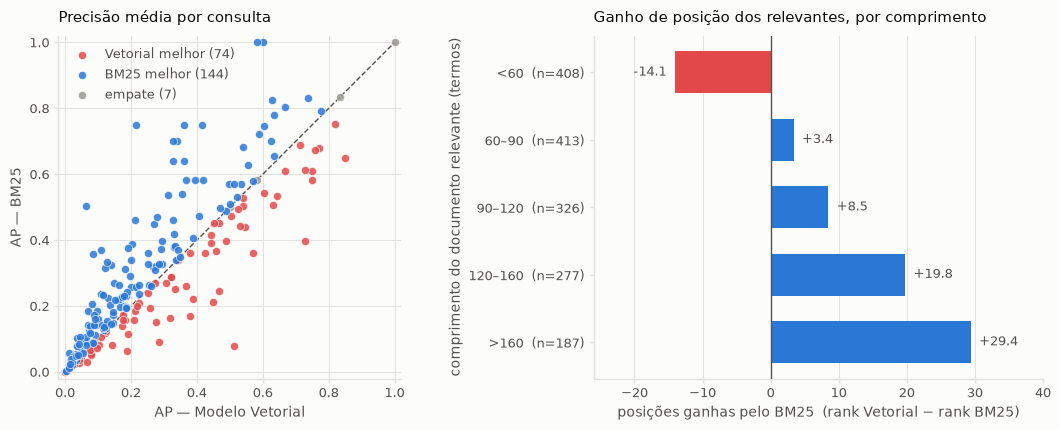

In [32]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e2e1dd"
C_BM25, C_VSM, C_TIE = "#2a78d6", "#e34948", "#9a9892"


def style_axes(ax):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
        ax.spines[side].set_linewidth(1)
    ax.tick_params(colors=INK2, labelsize=9, length=3, width=1, color=GRID)
    ax.xaxis.label.set_color(INK2)
    ax.yaxis.label.set_color(INK2)
    ax.set_axisbelow(True)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
fig.patch.set_facecolor(SURFACE)

ax = axes[0]
wins, losses, ties = by_query.delta > 0, by_query.delta < 0, by_query.delta == 0
ax.plot([0, 1], [0, 1], color=INK2, lw=1, ls="--", zorder=1)
ax.scatter(by_query.vetorial[losses], by_query.bm25[losses], s=34, c=C_VSM, alpha=.85,
           lw=.5, edgecolors=SURFACE, zorder=3, label=f"Vetorial melhor ({losses.sum()})")
ax.scatter(by_query.vetorial[wins], by_query.bm25[wins], s=34, c=C_BM25, alpha=.85,
           lw=.5, edgecolors=SURFACE, zorder=3, label=f"BM25 melhor ({wins.sum()})")
ax.scatter(by_query.vetorial[ties], by_query.bm25[ties], s=34, c=C_TIE, alpha=.85,
           lw=.5, edgecolors=SURFACE, zorder=2, label=f"empate ({ties.sum()})")
ax.set_xlabel("AP — Modelo Vetorial")
ax.set_ylabel("AP — BM25")
ax.set_title("Precisão média por consulta", color=INK, fontsize=11, loc="left", pad=10)
ax.set_xlim(-.02, 1.02); ax.set_ylim(-.02, 1.02); ax.set_aspect("equal")
ax.grid(True, color=GRID, lw=.7, zorder=0)
ax.legend(frameon=False, fontsize=9, loc="upper left", labelcolor=INK2)
style_axes(ax)

ax = axes[1]
ax.barh(range(len(bands)), bands.ganho_medio, height=.62, zorder=3,
        color=[C_BM25 if v > 0 else C_VSM for v in bands.ganho_medio])
ax.axvline(0, color=INK2, lw=1, zorder=4)
ax.set_yticks(range(len(bands)))
ax.set_yticklabels([f"{faixa}  (n={n})" for faixa, n in zip(bands.index, bands.n)])
ax.invert_yaxis()
ax.set_ylabel("comprimento do documento relevante (termos)")
ax.set_xlabel("posições ganhas pelo BM25  (rank Vetorial − rank BM25)")
ax.set_title("Ganho de posição dos relevantes, por comprimento", color=INK, fontsize=11, loc="left", pad=10)
for i, v in enumerate(bands.ganho_medio):
    ax.text(v + (1.2 if v > 0 else -1.2), i, f"{v:+.1f}", va="center",
            ha="left" if v > 0 else "right", fontsize=9, color=INK2)
ax.set_xlim(-26, 40)
ax.grid(True, axis="x", color=GRID, lw=.7, zorder=0)
style_axes(ax)

fig.tight_layout()
Path("results_req5").mkdir(parents=True, exist_ok=True)
fig.savefig("results_req5/comparacao_modelos.png", dpi=150, facecolor=SURFACE)
plt.show()

## Conclusão do requisito 5

**A média esconde a dispersão.** O BM25 tem MAP 12,2% superior (0,3050 contra 0,2718), mas não vence em toda consulta: ganha em **144**, perde em **74** e empata em 7. O gráfico de dispersão mostra pontos dos dois lados da diagonal ao longo de toda a faixa de AP — não é um modelo dominando o outro, é um modelo com vantagem na maioria dos casos.

**Os rankings são genuinamente diferentes.** A sobreposição média do Top-10 é de apenas **6,48 documentos em 10**. Em pelo menos uma consulta os dois modelos concordam em um único documento entre os dez primeiros. A comparação não é entre variações de um mesmo ranking.

**As maiores diferenças:**

| consulta | ΔAP | AP bm25 | AP vetorial | comprimento dos relevantes |
|---|---|---|---|---|
| 167 | +0,534 | 0,750 | 0,216 | 142, 195 |
| 36 | +0,438 | 0,503 | 0,064 | 76, 140 |
| 173 | +0,417 | 1,000 | 0,583 | 41, 66 |
| 148 | −0,239 | 0,211 | 0,450 | 32, 44, 45, 47, 91, 157 |
| 190 | −0,328 | 0,399 | 0,727 | 29, 29, 74, 75, 79 |
| 17 | −0,434 | 0,079 | 0,513 | 37, 92 |

**Hipótese: a diferença vem da normalização por comprimento.** Entre as três características testadas, a única que se correlaciona com o ΔAP é o comprimento médio dos documentos relevantes da consulta (r = 0,374); o tamanho da consulta (r = −0,067) e o número de relevantes (r = −0,069) são irrelevantes.

A verificação no nível do documento confirma, sobre os 1612 pares (consulta, documento relevante). O ganho médio de posição do BM25 cresce monotonicamente com o comprimento do documento:

| comprimento | n | rank médio Vetorial | rank médio BM25 | ganho |
|---|---|---|---|---|
| <60 | 408 | 194,2 | 208,3 | −14,1 |
| 60–90 | 413 | 161,8 | 158,4 | +3,4 |
| 90–120 | 326 | 192,2 | 183,8 | +8,5 |
| 120–160 | 277 | 127,3 | 107,4 | +19,8 |
| >160 | 187 | 130,5 | 101,1 | +29,4 |

Em documentos relevantes acima de 120 termos, o BM25 leva **157** ao Top-10 contra 105 do Vetorial (+50%); abaixo de 60 termos a relação se inverte (128 contra 158).

**A explicação está na forma das duas normalizações.** O cosseno divide pelo módulo $\lVert \vec{d} \rVert$, que cresce com *todos* os termos do documento, inclusive os que nada têm a ver com a consulta — um documento longo é penalizado mesmo quando é longo por tratar o assunto em profundidade. O BM25 normaliza de forma parcial e ajustável: com $b = 0{,}75$, apenas 75% do desvio em relação a `avgdl` é descontado, e o desconto age sobre a saturação da tf, não sobre o score inteiro. O resultado é que o BM25 recupera documentos relevantes longos que o Modelo Vetorial desconsidera.

Isso é consistente com as consultas extremas: os relevantes da consulta 167 têm 142 e 195 termos, bem acima da média de 94,8, e o BM25 ganha 0,534 de AP; os da consulta 190 têm 29 a 79 termos, todos abaixo da média, e o Vetorial ganha 0,328.

**É uma tendência, não uma lei.** A consulta 173 contraria o padrão: seus relevantes têm 41 e 66 termos e ainda assim o BM25 vence por 0,417. A correlação de 0,374 explica parte da variância, não toda. Outros fatores, como a raridade dos termos da consulta, também pesam.

# Requisito 6 - Análise por consulta

## Decisões de projeto

**Seleção guiada pelo ΔAP do requisito 5.** As consultas dos casos (i) e (ii) são as de maior diferença absoluta entre os modelos, não escolhidas à mão. Para o caso (iii), tomamos as consultas em que **ambos** os modelos têm P@10 = 0 e AP próximo de zero.

**Configuração fixada em `stopwords+stemming`**, a mesma do requisito 5.

**Exibição.** Para cada consulta, os cinco primeiros documentos de cada modelo, com `R` marcando os relevantes segundo o qrels (grau ≥ 1), o comprimento do documento em termos e o título. O comprimento aparece porque é a variável que o requisito 5 apontou como explicação.

### Função de exibição

In [33]:
def compare_top(query_id, k=5):
    """Top-k dos dois modelos para uma consulta, lado a lado com relevância e comprimento."""
    lengths = sorted(bm25_model.doc_lens[doc_position[d]] for d in relevant[query_id])
    print(f"CONSULTA {query_id} — {' '.join(query_text[query_id].split())}")
    print(f"{len(relevant[query_id])} relevantes, comprimentos {lengths}  (avgdl {bm25_model.avg_len:.1f})")
    print(f"AP: bm25 {by_query.loc[query_id, 'bm25']:.3f}   vetorial {by_query.loc[query_id, 'vetorial']:.3f}")

    for name, rankings in all_rankings.items():
        print(f"\n  {name}")
        for position, (doc_idx, score) in enumerate(rankings[COMPARE_CONFIG][query_id][:k], 1):
            doc_id = doc_ids[doc_idx]
            mark = "R" if doc_id in relevant[query_id] else " "
            title = " ".join(docs["title"][doc_idx].split())[:52]
            print(f"    {position}. [{mark}] doc {doc_id:>4s}  |d|={bm25_model.doc_lens[doc_idx]:3d}"
                  f"  {score:7.3f}  {title}")
    print()

### i) Consultas em que o BM25 é superior

In [34]:
for query_id in by_query.nlargest(2, "delta").index:
    compare_top(query_id)

CONSULTA 167 — exact solution methods for calculating the ablative mass loss of a material ablating at high temperatures in a hypersonic flight environment .
2 relevantes, comprimentos [142, 195]  (avgdl 94.8)
AP: bm25 0.750   vetorial 0.216

  vetorial
    1. [ ] doc  553  |d|= 98    0.242  ablation of glassy materials around blunt bodies of 
    2. [ ] doc 1279  |d|= 92    0.214  sublimation in a hypersonic environment .
    3. [ ] doc 1099  |d|= 43    0.211  a theoretical study of stagnation point ablation .
    4. [R] doc  274  |d|=142    0.177  analysis of quartz and teflon shields for a particul
    5. [ ] doc 1100  |d|= 78    0.162  an analytical investigation of ablation .

  bm25
    1. [R] doc  274  |d|=142   23.812  analysis of quartz and teflon shields for a particul
    2. [ ] doc 1279  |d|= 92   23.221  sublimation in a hypersonic environment .
    3. [ ] doc  553  |d|= 98   22.849  ablation of glassy materials around blunt bodies of 
    4. [R] doc   82  |d|=195   20.480

### ii) Consultas em que o Modelo Vetorial é superior

In [35]:
for query_id in by_query.nsmallest(2, "delta").index:
    compare_top(query_id)

CONSULTA 17 — can the three-dimensional problem of a transverse potential flow about a body of revolution be reduced to a two-dimensional problem .
2 relevantes, comprimentos [37, 92]  (avgdl 94.8)
AP: bm25 0.079   vetorial 0.513

  vetorial
    1. [R] doc  106  |d|= 37    0.287  the transverse potential flow past a body of revolut
    2. [ ] doc  336  |d|= 49    0.226  simplified laminar boundary layer calculations for b
    3. [ ] doc  326  |d|= 33    0.209  forst-order slip effects on the compressible laminar
    4. [ ] doc  498  |d|= 86    0.197  calculation of potential flow about bodies of revolu
    5. [ ] doc 1108  |d|=148    0.187  a study of second-order supersonic flow theory .

  bm25
    1. [ ] doc 1108  |d|=148   22.368  a study of second-order supersonic flow theory .
    2. [ ] doc 1281  |d|=130   20.713  turbulent heat transfer on blunt-nosed bodies in two
    3. [ ] doc  336  |d|= 49   20.469  simplified laminar boundary layer calculations for b
    4. [ ] doc  700  |

### iii) Consultas em que ambos têm desempenho insatisfatório

In [36]:
p10 = comparison.pivot(index="query_id", columns="modelo", values="P@10")
both_fail = by_query[(p10["bm25"] == 0) & (p10["vetorial"] == 0)].copy()
both_fail["melhor_ap"] = both_fail[["bm25", "vetorial"]].max(axis=1)

worst = both_fail.nsmallest(2, "melhor_ap").index
print(f"{len(both_fail)} consultas com P@10 = 0 nos dois modelos; as duas piores: {list(worst)}\n")

for query_id in worst:
    compare_top(query_id)

27 consultas com P@10 = 0 nos dois modelos; as duas piores: ['13', '22']

CONSULTA 13 — what is the basic mechanism of the transonic aileron buzz .
4 relevantes, comprimentos [49, 49, 91, 107]  (avgdl 94.8)
AP: bm25 0.000   vetorial 0.000

  vetorial
    1. [ ] doc  496  |d|= 69    0.463  a theory of transonic aileron buzz, neglecting visco
    2. [ ] doc  903  |d|=123    0.215  two dimensional transonic unsteady flow with shock w
    3. [ ] doc  520  |d|=135    0.157  wing-tail interference as a cause of 'magnus' effect
    4. [ ] doc  313  |d|= 34    0.146  on alternative forms for the basic equations of tran
    5. [ ] doc  643  |d|= 79    0.146  an investigation of wing-aileron flutter using groun

  bm25
    1. [ ] doc  496  |d|= 69   23.680  a theory of transonic aileron buzz, neglecting visco
    2. [ ] doc  903  |d|=123   14.339  two dimensional transonic unsteady flow with shock w
    3. [ ] doc  520  |d|=135   12.036  wing-tail interference as a cause of 'magnus' effect
    4

### Diagnóstico das consultas com falha total

Quais termos da consulta aparecem em cada documento relevante.

In [37]:
for query_id in worst:
    terms = query_tokens[COMPARE_CONFIG][query_ids.index(query_id)]
    print(f"CONSULTA {query_id} — termos: {terms}")
    print("  df na coleção: "
          + ", ".join(f"{t}={len(bm25_model.index[t])}" if t in bm25_model.index else f"{t}=AUSENTE"
                      for t in dict.fromkeys(terms)))
    for doc_id in sorted(relevant[query_id]):
        doc_idx = doc_position[doc_id]
        present = [t for t in dict.fromkeys(terms) if t in set(doc_tokens[COMPARE_CONFIG][doc_idx])]
        title = " ".join(docs["title"][doc_idx].split())[:58]
        print(f"    doc {doc_id:>4s}  termos em comum: {present if present else 'NENHUM'}   {title}")
    print()

CONSULTA 13 — termos: ['basic', 'mechan', 'transon', 'aileron', 'buzz']
  df na coleção: basic=41, mechan=46, transon=63, aileron=9, buzz=1
    doc  265  termos em comum: NENHUM   some instabilities arising from the interaction between sh
    doc  311  termos em comum: NENHUM   a method for predicting the onset of buffeting and other s
    doc   64  termos em comum: NENHUM   unsteady oblique interaction of a shock wave with plane di
    doc   65  termos em comum: NENHUM   convection of a pattern of vorticity through a shock wave 

CONSULTA 22 — termos: ['anyon', 'els', 'discov', 'turbul', 'skin', 'friction', 'sensit', 'natur', 'variat', 'viscos', 'temperatur']
  df na coleção: anyon=AUSENTE, els=AUSENTE, discov=5, turbul=144, skin=95, friction=88, sensit=16, natur=55, variat=141, viscos=63, temperatur=268
    doc   68  termos em comum: NENHUM   some aspects of air-helium simulation and hypersonic appro



## Conclusão do requisito 6

### i) BM25 superior — consultas 167 e 36

Na **consulta 167** (*exact solution methods for calculating the ablative mass loss...*) os dois relevantes têm 142 e 195 termos, muito acima do `avgdl` de 94,8. O BM25 coloca o doc 274 em **1º** e o doc 82 em 4º; o Modelo Vetorial só alcança o doc 274 na 4ª posição e não traz o doc 82 entre os cinco primeiros. O topo do ranking vetorial é ocupado por documentos de 98, 92 e 43 termos — mais curtos e, portanto, menos penalizados pela divisão.

Na **consulta 36** o efeito é mais extremo: o BM25 traz o doc 168 (140 termos) em 1º, e o Modelo Vetorial **não recupera nenhum relevante** no Top-5. Note que os cinco primeiros do BM25 têm 140, 140, 118, 112 e 120 termos — todos acima da média.

Ambos os casos são a manifestação individual do padrão agregado do requisito 5: a normalização total do cosseno inviabiliza documentos relevantes longos.

### ii) Modelo Vetorial superior — consultas 17 e 190

O padrão se inverte exatamente como previsto. Na **consulta 17**, o doc relevante 106 tem apenas **37 termos**, menos da metade do `avgdl`. O Modelo Vetorial o coloca em **1º**; o BM25 não traz nenhum relevante no Top-5, e seus cinco primeiros têm 148, 130, 49, 69 e 93 termos.

Na **consulta 190**, cujos cinco relevantes têm de 29 a 79 termos (todos abaixo da média), o Modelo Vetorial coloca **três** no Top-5 (docs 390, 391 e 15) contra **dois** do BM25, que intercala documentos de 142 e 134 termos nas posições 3 e 5.

A simetria entre os casos (i) e (ii) é a evidência mais forte de que a diferença entre os modelos é a normalização por comprimento, e não uma vantagem genérica de um sobre o outro.

### iii) Ambos insatisfatórios — consultas 13 e 22

Há **27 consultas** com P@10 = 0 nos dois modelos. As duas piores têm AP **exatamente 0,000**: nenhum relevante aparece em posição alguma do ranking. O diagnóstico mostra que a causa não é de ponderação — é **descasamento de vocabulário**:

| consulta | termos da consulta | termos em comum com os relevantes |
|---|---|---|
| 13 | `basic`, `mechan`, `transon`, `aileron`, `buzz` | **nenhum**, nos 4 relevantes |
| 22 | `turbul`, `skin`, `friction`, `sensit`, `viscos`, `temperatur`, ... | **nenhum**, no único relevante |

Nos dois casos nenhum modelo recupera qualquer documento relevante, porque o vocabulário da consulta e o dos documentos julgados relevantes não se encontram: a interseção de termos é vazia e o score é zero por construção, de modo que nenhuma mudança de ponderação, de `k1` ou de `b` altera o resultado — a consulta 13 pergunta pelo mecanismo do *transonic aileron buzz* enquanto seus relevantes descrevem o mesmo fenômeno como *shock wave / boundary layer interaction*, *buffeting* e *vorticity*, e a consulta 22 desperdiça termos por ser conversacional (`anyon` e `els` não existem na coleção), ao passo que o termo mais discriminativo da consulta 13, `buzz`, tem df = 1 e serve apenas para puxar ao topo o doc 496 (*a theory of transonic aileron buzz, neglecting viscosity*), de título quase literal e ainda assim julgado não relevante — sinal de que sobreposição lexical e relevância são coisas diferentes. Corrigir isso exige sair do casamento de termos: expansão de consulta ou, principalmente, uma representação semântica capaz de aproximar *buzz* de *shock wave interaction* sem depender de os dois textos usarem a mesma palavra.

# Requisito 7 - Variação dos parâmetros do BM25

## Decisões de projeto

**Grid completo 3 × 3**, com os valores exigidos pelo enunciado: $k_1 \in \{0{,}5;\ 1{,}2;\ 2{,}0\}$ e $b \in \{0;\ 0{,}75;\ 1\}$ — nove avaliações sobre as 225 consultas.

**Segunda métrica: NDCG@10.** É a escolha que menos "coincide" com o MAP. NDCG@10 muda em duas dimensões ao mesmo tempo — usa **relevância graduada** e é **sensível à posição no topo**.

**O índice não é reconstruído.** Como decidido no requisito 3, $k_1$ e $b$ são parâmetros de busca: as nove configurações reutilizam o mesmo modelo, e o que varia é só o cálculo do score.

**Configuração de pré-processamento fixada em `stopwords+stemming`**, como no requisito 5.

### Grid de parâmetros

In [38]:
K1_VALUES = [0.5, 1.2, 2.0]
B_VALUES = [0.0, 0.75, 1.0]

grid_rows = []
for k1 in K1_VALUES:
    for b in B_VALUES:
        aps, ndcgs = [], []
        for i, query_id in enumerate(query_ids):
            ranking = bm25_search(bm25_model, query_tokens[COMPARE_CONFIG][i], k1=k1, b=b)
            ranked = [doc_ids[doc_idx] for doc_idx, _ in ranking]
            aps.append(average_precision(ranked, relevant[query_id]))
            ndcgs.append(ndcg_at_k(ranked, grades[query_id]))
        grid_rows.append({
            "k1": k1,
            "b": b,
            "MAP": sum(aps) / len(aps),
            "NDCG@10": sum(ndcgs) / len(ndcgs),
        })

param_grid = pd.DataFrame(grid_rows)

print("MAP")
print(param_grid.pivot(index="k1", columns="b", values="MAP").round(4).to_string())
print("\nNDCG@10")
print(param_grid.pivot(index="k1", columns="b", values="NDCG@10").round(4).to_string())

melhor = param_grid.loc[param_grid["MAP"].idxmax()]
padrao = param_grid[(param_grid.k1 == 1.2) & (param_grid.b == 0.75)].iloc[0]
print(f"\nmelhor MAP:  k1={melhor.k1}  b={melhor.b}  ->  {melhor['MAP']:.4f}")
print(f"padrão:      k1=1.2  b=0.75  ->  {padrao['MAP']:.4f}"
      f"   ({(melhor['MAP'] / padrao['MAP'] - 1) * 100:+.1f}%)")

MAP
b      0.00    0.75    1.00
k1                         
0.5  0.2668  0.2902  0.2925
1.2  0.2756  0.3050  0.3010
2.0  0.2798  0.3106  0.3066

NDCG@10
b      0.00    0.75    1.00
k1                         
0.5  0.3224  0.3475  0.3506
1.2  0.3337  0.3676  0.3663
2.0  0.3371  0.3734  0.3670

melhor MAP:  k1=2.0  b=0.75  ->  0.3106
padrão:      k1=1.2  b=0.75  ->  0.3050   (+1.8%)


### Gráfico

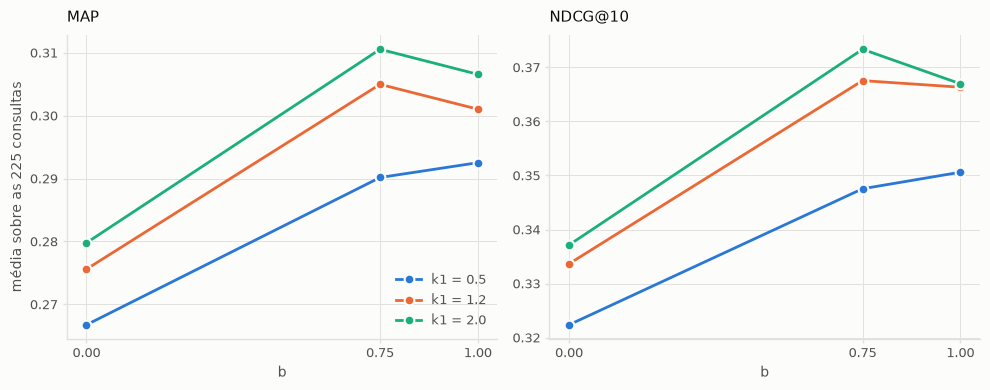

In [39]:
C_K1 = ["#2a78d6", "#eb6834", "#1baf7a"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
fig.patch.set_facecolor(SURFACE)

for ax, metric in zip(axes, ["MAP", "NDCG@10"]):
    for color, k1 in zip(C_K1, K1_VALUES):
        serie = param_grid[param_grid.k1 == k1]
        ax.plot(serie.b, serie[metric], color=color, lw=2, marker="o", ms=7,
                mec=SURFACE, mew=1.5, label=f"k1 = {k1}", zorder=3)
    ax.set_xlabel("b")
    ax.set_title(metric, color=INK, fontsize=11, loc="left", pad=10)
    ax.set_xticks(B_VALUES)
    ax.grid(True, color=GRID, lw=.7, zorder=0)
    style_axes(ax)

axes[0].set_ylabel("média sobre as 225 consultas")
axes[0].legend(frameon=False, fontsize=9, loc="lower right", labelcolor=INK2)

fig.tight_layout()
Path("results_req7").mkdir(parents=True, exist_ok=True)
fig.savefig("results_req7/grid_bm25.png", dpi=150, facecolor=SURFACE)
plt.show()

### Consulta em que `b` altera o ranking de forma perceptível

Procuramos a consulta com menor sobreposição de Top-10 entre `b=0` e `b=1`, com $k_1$ fixo em 1,2.

In [40]:
def top10_ids(query_id, k1=1.2, b=0.75):
    i = query_ids.index(query_id)
    ranking = bm25_search(bm25_model, query_tokens[COMPARE_CONFIG][i], k1=k1, b=b, top_k=10)
    return [doc_ids[doc_idx] for doc_idx, _ in ranking]


sensitivity = pd.Series(
    {q: len(set(top10_ids(q, b=0.0)) & set(top10_ids(q, b=1.0))) for q in query_ids}
).sort_values()

print("menor sobreposição de Top-10 entre b=0 e b=1:")
for query_id, shared in sensitivity.head(5).items():
    ap0 = average_precision(top10_ids(query_id, b=0.0), relevant[query_id])
    ap1 = average_precision(top10_ids(query_id, b=1.0), relevant[query_id])
    print(f"  consulta {query_id:>4s}: {shared}/10 em comum   AP@10 {ap0:.3f} -> {ap1:.3f}")

menor sobreposição de Top-10 entre b=0 e b=1:
  consulta  124: 2/10 em comum   AP@10 0.000 -> 0.000
  consulta  218: 2/10 em comum   AP@10 0.118 -> 0.093
  consulta   84: 3/10 em comum   AP@10 0.273 -> 0.325
  consulta    6: 3/10 em comum   AP@10 0.083 -> 0.125
  consulta  161: 3/10 em comum   AP@10 0.417 -> 0.500


In [41]:
SELECTED = "161"

lengths = sorted(bm25_model.doc_lens[doc_position[d]] for d in relevant[SELECTED])
print(f"CONSULTA {SELECTED} — {' '.join(query_text[SELECTED].split())}")
print(f"{len(relevant[SELECTED])} relevantes, comprimentos {lengths}  (avgdl {bm25_model.avg_len:.1f})\n")

i = query_ids.index(SELECTED)
for b in (0.0, 0.75, 1.0):
    ranking = bm25_search(bm25_model, query_tokens[COMPARE_CONFIG][i], k1=1.2, b=b, top_k=5)
    media = sum(bm25_model.doc_lens[doc_idx] for doc_idx, _ in ranking) / len(ranking)
    print(f"  b = {b}   (|d| médio do Top-5: {media:.0f} termos)")
    for position, (doc_idx, score) in enumerate(ranking, 1):
        doc_id = doc_ids[doc_idx]
        mark = "R" if doc_id in relevant[SELECTED] else " "
        title = " ".join(docs["title"][doc_idx].split())[:46]
        print(f"    {position}. [{mark}] doc {doc_id:>4s}  |d|={bm25_model.doc_lens[doc_idx]:3d}"
              f"  {score:7.3f}  {title}")
    print()

CONSULTA 161 — is there an integral method to give a single and sufficiently accurate method of calculating the laminar separate point for various incompressible and compressible boundary layers with zero heat transfer .
6 relevantes, comprimentos [49, 81, 119, 131, 135, 182]  (avgdl 94.8)

  b = 0.0   (|d| médio do Top-5: 218 termos)
    1. [R] doc 1386  |d|=135   37.109  analysis and calculation by integral methods o
    2. [R] doc   54  |d|=131   31.771  method for calculation of compressible laminar
    3. [ ] doc  329  |d|=376   28.772  various aerodynamic characteristics in hyperso
    4. [ ] doc  962  |d|=232   27.965  contributions to the theory of heat transfer t
    5. [ ] doc  364  |d|=214   25.886  a method for analysing the insulating properti

  b = 0.75   (|d| médio do Top-5: 95 termos)
    1. [R] doc 1386  |d|=135   33.643  analysis and calculation by integral methods o
    2. [R] doc   54  |d|=131   28.459  method for calculation of compressible laminar
    3. [R] doc 

## Conclusão do requisito 7

**MAP**

| k1 \\ b | 0,00 | 0,75 | 1,00 |
|---|---|---|---|
| 0,5 | 0,2668 | 0,2902 | 0,2925 |
| 1,2 | 0,2756 | 0,3050 | 0,3010 |
| 2,0 | 0,2798 | **0,3106** | 0,3066 |

**NDCG@10**

| k1 \\ b | 0,00 | 0,75 | 1,00 |
|---|---|---|---|
| 0,5 | 0,3224 | 0,3475 | 0,3506 |
| 1,2 | 0,3337 | 0,3676 | 0,3663 |
| 2,0 | 0,3371 | **0,3734** | 0,3670 |

**As duas métricas concordam.** O melhor ponto do grid é $k_1 = 2{,}0$, $b = 0{,}75$ em MAP (0,3106) e em NDCG@10 (0,3734), e a ordenação das nove células é praticamente a mesma nas duas. Isso é um bom sinal: o ganho não é artefato de um corte de ranking ou da definição binária de relevância. O ganho sobre o padrão ($k_1 = 1{,}2$, $b = 0{,}75$) é de apenas **+1,8%** em MAP — pequeno diante da diferença entre modelos (+12,2%) ou do pré-processamento (+13,2%).

**`b` pesa mais que `k1`, e `b = 0` é a única escolha claramente ruim.** Com $k_1 = 1{,}2$, variar `b` move o MAP de 0,2756 a 0,3050 (+10,7%); com $b = 0{,}75$, variar `k1` move de 0,2902 a 0,3106 (+7,0%). O efeito de `k1` não é desprezível, mas é o de `b` que domina, e é monotônico apenas na primeira metade: de $b=0$ para $b=0{,}75$ o ganho é grande, e de $0{,}75$ para $1$ há leve **perda** em MAP (exceto em $k_1 = 0{,}5$). Ou seja, alguma normalização é essencial, normalização total é excessiva — o valor convencional 0,75 está bem calibrado para esta coleção.

**`k1` maior é melhor aqui.** $k_1 = 2{,}0$ vence em todas as três colunas. $k_1$ alto significa saturação mais lenta, isto é, mais crédito para repetições do termo. Como a Cranfield é composta de resumos técnicos curtos e temáticamente concentrados, repetir um termo é de fato sinal de que o documento trata daquele assunto, e não de preenchimento — o que justifica saturar devagar.

**Consulta 161: `b` reorganiza o ranking.** É a melhor ilustração do efeito, com apenas 3 dos 10 primeiros documentos em comum entre $b=0$ e $b=1$:

| b | comprimento médio do Top-5 | relevantes no Top-5 |
|---|---|---|
| 0,00 | 218 termos | 2 |
| 0,75 | 95 termos | 3 |
| 1,00 | 95 termos | 3 |

Com $b = 0$ não há desconto por comprimento e o Top-5 é tomado por documentos de 376, 232 e 214 termos: eles acumulam tf alto simplesmente por serem longos. Ligando a normalização, o comprimento médio do Top-5 cai para 95 termos, praticamente o `avgdl` da coleção (94,8), o documento 55 — relevante, com 81 termos — entra na 3ª posição, e o AP calculado sobre o Top-10 sobe de 0,417 para 0,500.

Vale notar que $b = 0{,}75$ e $b = 1$ produzem aqui o **mesmo** Top-5, em ordem idêntica: o salto está inteiramente entre $b=0$ e $b=0{,}75$, o que é coerente com o grid agregado, onde a diferença entre 0,75 e 1 é de terceira casa decimal.

Isso confirma diretamente, manipulando o parâmetro, a hipótese que os requisitos 5 e 6 levantaram por observação: **a normalização por comprimento é o eixo que separa os dois modelos**. O Modelo Vetorial se comporta como um extremo rígido dessa escala — normaliza sempre pelo módulo completo do vetor, sem um parâmetro que controle a rigidez.

# Requisito 8 - Modificação de consultas

## Decisões de projeto

**As reformulações não usam os qrels.** Cada versão alternativa foi escrita somente a partir do **texto da consulta** e de **conhecimento do domínio**

**Cobertura dos tipos sugeridos:** remoção de termos, acréscimo de termos e sinônimos, consulta mais genérica e consulta mais específica.

**Métricas de Top-10.** Como a análise pedida é sobre o Top-10, usamos P@10 e NDCG@10 — as mesmas duas do requisito 7. Reportamos também quantos dos dez documentos foram trocados, que mede a mudança do ranking (independentemente se foi boa ou ruim).

**Ambos os modelos**, na configuração `stopwords+stemming` com $k_1 = 1{,}2$ e $b = 0{,}75$. As consultas modificadas passam pelo mesmo pré-processamento das originais.

### As cinco reformulações

In [42]:
REFORMULATIONS = {
    "22": (
        "turbulent skin friction viscosity variation with temperature",
        "remoção de termos não-conteúdo",
    ),
    "13": (
        "transonic aileron buzz shock wave boundary layer interaction control surface oscillation",
        "acréscimo de termos do domínio",
    ),
    "82": (
        "methods for calculating lift distribution on swept wings in subsonic flow",
        "remoção de nomes próprios",
    ),
    "200": (
        "buckling stresses in torispherical shells",
        "tornar mais genérica",
    ),
    "95": (
        "theoretical heat transfer distribution around a hemisphere blunt nosed body stagnation point",
        "tornar mais específica",
    ),
}

for query_id, (modificada, tipo) in REFORMULATIONS.items():
    print(f"consulta {query_id} — {tipo}")
    print(f"  original:   {' '.join(query_text[query_id].split())}")
    print(f"  modificada: {modificada}\n")

consulta 22 — remoção de termos não-conteúdo
  original:   did anyone else discover that the turbulent skin friction is not over sensitive to the nature of the variation of the viscosity with temperature .
  modificada: turbulent skin friction viscosity variation with temperature

consulta 13 — acréscimo de termos do domínio
  original:   what is the basic mechanism of the transonic aileron buzz .
  modificada: transonic aileron buzz shock wave boundary layer interaction control surface oscillation

consulta 82 — remoção de nomes próprios
  original:   how do kuchemann's and multhopp's methods for calculating lift distributions on swept wings in subsonic flow compare with each other and with experiment .
  modificada: methods for calculating lift distribution on swept wings in subsonic flow

consulta 200 — tornar mais genérica
  original:   are asymptotic methods sufficiently accurate in the determination of pre-buckling stresses in torispherical shells, or must we resort to numerical 

### Execução e comparação

In [43]:
def search_text(text, model_name, k=10):
    """Roda um texto livre de consulta em um dos modelos e devolve os k primeiros doc_ids."""
    terms = preprocess(text, **CONFIGS[COMPARE_CONFIG])
    if model_name == "bm25":
        ranking = bm25_search(bm25_models[COMPARE_CONFIG], terms, top_k=k)
    else:
        ranking = vsm_search(vsm_models[COMPARE_CONFIG], terms, top_k=k)
    return [doc_ids[doc_idx] for doc_idx, _ in ranking]


reform_rows = []
for query_id, (modificada, tipo) in REFORMULATIONS.items():
    for model_name in all_rankings:
        original_top = search_text(query_text[query_id], model_name)
        modified_top = search_text(modificada, model_name)
        reform_rows.append({
            "consulta": query_id,
            "tipo": tipo,
            "modelo": model_name,
            "P@10 orig": precision_at_k(original_top, relevant[query_id]),
            "P@10 mod": precision_at_k(modified_top, relevant[query_id]),
            "NDCG@10 orig": round(ndcg_at_k(original_top, grades[query_id]), 3),
            "NDCG@10 mod": round(ndcg_at_k(modified_top, grades[query_id]), 3),
            "trocados": 10 - len(set(original_top) & set(modified_top)),
        })

reformulations = pd.DataFrame(reform_rows)
reformulations

,consulta,tipo,modelo,P@10 orig,P@10 mod,NDCG@10 orig,NDCG@10 mod,trocados
0,22,remoção de termos não-conteúdo,vetorial,0.0,0.0,0.000,0.000,3
1,22,remoção de termos não-conteúdo,bm25,0.0,0.0,0.000,0.000,1
2,13,acréscimo de termos do domínio,vetorial,0.0,0.1,0.000,0.184,6
3,13,acréscimo de termos do domínio,bm25,0.0,0.1,0.000,0.199,7
4,82,remoção de nomes próprios,vetorial,0.2,0.2,0.517,0.517,2
5,82,remoção de nomes próprios,bm25,0.3,0.2,0.540,0.275,3
6,200,tornar mais genérica,vetorial,0.1,0.1,0.235,0.296,6
7,200,tornar mais genérica,bm25,0.2,0.1,0.370,0.296,6
8,95,tornar mais específica,vetorial,0.1,0.1,0.065,0.272,6
9,95,tornar mais específica,bm25,0.2,0.2,0.416,0.411,4


### Efeito agregado sobre as cinco consultas

In [44]:
resumo = pd.DataFrame({
    "P@10": [reformulations["P@10 orig"].mean(), reformulations["P@10 mod"].mean()],
    "NDCG@10": [reformulations["NDCG@10 orig"].mean(), reformulations["NDCG@10 mod"].mean()],
}, index=["original", "modificada"]).round(4)

print(resumo.to_string())
print(f"\ndocumentos trocados no Top-10: média {reformulations.trocados.mean():.1f} de 10")

melhorou = (reformulations["NDCG@10 mod"] > reformulations["NDCG@10 orig"]).sum()
piorou = (reformulations["NDCG@10 mod"] < reformulations["NDCG@10 orig"]).sum()
igual = len(reformulations) - melhorou - piorou
print(f"NDCG@10 por caso (5 consultas x 2 modelos):"
      f"  melhorou {melhorou}, piorou {piorou}, inalterado {igual}")

            P@10  NDCG@10
original    0.11   0.2143
modificada  0.11   0.2450

documentos trocados no Top-10: média 4.4 de 10
NDCG@10 por caso (5 consultas x 2 modelos):  melhorou 4, piorou 3, inalterado 3


### Caso 1 — consulta 13: a expansão quebra o descasamento de vocabulário

Era uma das duas consultas com AP zero no requisito 6.

In [45]:
modificada_13 = REFORMULATIONS["13"][0]
print(f"original:   {' '.join(query_text['13'].split())}")
print(f"modificada: {modificada_13}\n")

for rotulo, texto in (("ORIGINAL", query_text["13"]), ("MODIFICADA", modificada_13)):
    top = search_text(texto, "bm25")
    encontrados = [d for d in top if d in relevant["13"]]
    print(f"  {rotulo}: relevantes no Top-10 = {encontrados if encontrados else 'nenhum'}")
    for position, doc_id in enumerate(top[:5], 1):
        mark = "R" if doc_id in relevant["13"] else " "
        title = " ".join(docs["title"][doc_position[doc_id]].split())[:52]
        print(f"    {position}. [{mark}] doc {doc_id:>4s}  {title}")
    print()

original:   what is the basic mechanism of the transonic aileron buzz .
modificada: transonic aileron buzz shock wave boundary layer interaction control surface oscillation

  ORIGINAL: relevantes no Top-10 = nenhum
    1. [ ] doc  496  a theory of transonic aileron buzz, neglecting visco
    2. [ ] doc  903  two dimensional transonic unsteady flow with shock w
    3. [ ] doc  520  wing-tail interference as a cause of 'magnus' effect
    4. [ ] doc  313  on alternative forms for the basic equations of tran
    5. [ ] doc  440  compilation of information on the transonic attachme

  MODIFICADA: relevantes no Top-10 = ['265']
    1. [ ] doc  496  a theory of transonic aileron buzz, neglecting visco
    2. [ ] doc  903  two dimensional transonic unsteady flow with shock w
    3. [ ] doc  335  the interaction between boundary layer and shock wav
    4. [ ] doc  798  interaction between shock waves and boundary layers,
    5. [R] doc  265  some instabilities arising from the interaction bet

### Caso 2 — consulta 82: os nomes próprios não eram ruído

In [46]:
for termo in ("kuchemann", "multhopp"):
    radical = stem(termo)
    modelo = bm25_models[COMPARE_CONFIG]
    if radical in modelo.index:
        print(f"{termo:10s} -> '{radical}'  df={len(modelo.index[radical])}  idf={modelo.idf[radical]:.2f}")
    else:
        print(f"{termo:10s} -> '{radical}'  AUSENTE da coleção")

print()
for rotulo, texto in (("original", query_text["82"]), ("modificada", REFORMULATIONS["82"][0])):
    top = search_text(texto, "bm25")
    marcados = " ".join(("R" if d in relevant["82"] else ".") + d for d in top[:5])
    print(f"  {rotulo:11s} {marcados}")

kuchemann  -> 'kuchemann'  df=1  idf=6.84
multhopp   -> 'multhopp'  AUSENTE da coleção

  original    R678 .1334 .1339 .247 R676
  modificada  .1334 .1339 R678 .247 .1332


## Conclusão do requisito 8

| consulta | tipo | modelo | P@10 | NDCG@10 | trocados |
|---|---|---|---|---|---|
| 22 | remoção de termos não-conteúdo | vetorial | 0,0 → 0,0 | 0,000 → 0,000 | 3 |
| 22 | | bm25 | 0,0 → 0,0 | 0,000 → 0,000 | 1 |
| 13 | acréscimo de termos do domínio | vetorial | 0,0 → **0,1** | 0,000 → **0,184** | 6 |
| 13 | | bm25 | 0,0 → **0,1** | 0,000 → **0,199** | 7 |
| 82 | remoção de nomes próprios | vetorial | 0,2 → 0,2 | 0,517 → 0,517 | 2 |
| 82 | | bm25 | 0,3 → 0,2 | 0,540 → **0,275** | 3 |
| 200 | tornar mais genérica | vetorial | 0,1 → 0,1 | 0,235 → 0,296 | 6 |
| 200 | | bm25 | 0,2 → 0,1 | 0,370 → 0,296 | 6 |
| 95 | tornar mais específica | vetorial | 0,1 → 0,1 | 0,065 → **0,272** | 6 |
| 95 | | bm25 | 0,2 → 0,2 | 0,416 → 0,411 | 4 |

**Reformular mexe muito no ranking, e as duas métricas discordam sobre o resultado.** Em média, **4,4 dos 10** documentos do Top-10 são trocados. O P@10 médio fica **idêntico** (0,1100 → 0,1100), mas o NDCG@10 médio **melhora** (0,2143 → 0,2450). Dos dez casos, quatro melhoram, três pioram e três ficam iguais em NDCG@10.

A leitura conjunta é o ponto interessante: como o P@10 não se move, as reformulações **não recuperaram mais documentos relevantes** — recuperaram documentos *mais* relevantes, ou os colocaram em posições melhores. O ganho é de qualidade do topo, não de cobertura. Essa distinção só aparece porque o NDCG@10 usa os graus; com métricas binárias o efeito seria invisível.

**O maior ganho é o caso que os requisitos 6 e 7 previram.** A consulta 13 tinha AP exatamente zero nos dois modelos porque nenhum termo seu aparecia nos documentos relevantes. Acrescentar a terminologia do mecanismo físico — *shock wave*, *boundary layer*, *interaction* — faz o documento 265 entrar no Top-10 nos dois modelos, na 5ª posição do BM25, levando o NDCG@10 de 0,000 a 0,184 e 0,199. Vale observar que a expansão também trouxe os documentos 335 e 798, ambos sobre interação choque/camada-limite e ambos **não** relevantes: expandir alarga o alcance da consulta de forma indiscriminada, e o relevante vem acompanhado de documentos parecidos. É a confirmação prática da conclusão do requisito 6: quando a falha é de vocabulário, só mudar a representação da consulta resolve.

**A consulta 22 continua em zero,** e isso era previsível. Remover os termos conversacionais eliminou ruído — `anyon` e `els` nem existiam na coleção — mas não *acrescentou* nada. Como o único documento relevante não compartilha nenhum termo com a consulta, limpar a consulta não cria a interseção que falta. Remoção de ruído e expansão de vocabulário resolvem problemas diferentes.

**O caso mais interessante é a falha da consulta 82.** A intuição de que nomes de autores são ruído está errada aqui: `kuchemann` tem **df = 1** e **idf = 6,84**, e apontava justamente para o artigo relevante — removê-lo derrubou o NDCG@10 do BM25 de 0,540 para **0,275**, e o documento 678 caiu da 1ª para a 3ª posição. Já `multhopp` **sequer existe na coleção**, de modo que metade da premissa da reformulação era vazia desde o início.

A lição generaliza o que o requisito 6 mostrou pelo avesso: um termo de df muito baixo é uma aposta de alto risco. Quando ele casa com o documento certo, como aqui, é o sinal mais forte da consulta; quando casa com o documento errado, como o `buzz` da consulta 13, envenena o topo do ranking. Em ambos os casos, o idf o torna decisivo.

**As reformulações de generalidade (200) e especificidade (95) continuam sem direção consistente.** Generalizar a 200 melhorou o Modelo Vetorial (0,235 → 0,296) e piorou o BM25 (0,370 → 0,296). Especificar a 95 melhorou muito o Vetorial (0,065 → 0,272) e deixou o BM25 praticamente parado (0,416 → 0,411). O mesmo texto de consulta produz efeitos opostos nos dois modelos, o que reforça que a reformulação manual interage com o modelo e não é uma melhoria independente dele.

# Requisito 9 - Análise de erros

## Decisões de projeto

**Seleção por critério programático.** Os casos não foram escolhidos a dedo. Para os não relevantes no topo, filtramos os documentos em **1ª posição** que o qrels julga com grau **−1**. Para o relevante fora do Top-10, tomamos os de **grau 1** — o mais relevante da escala da Cranfield, *references which are a complete answer to the question* — com a pior posição entre os efetivamente recuperados.

**Por que grau 1 e não qualquer relevante.** Um documento de grau 4 (*minimum interest*, incluído por motivo histórico) mal colocado é um erro menor; um documento que é a resposta completa da pergunta e não aparece no Top-10 é a falha mais séria possível.

**Modelo de referência: BM25** na configuração `stopwords+stemming`, $k_1 = 1{,}2$, $b = 0{,}75$, por ser o modelo que obteve melhores métricas.

### Seleção dos casos

In [47]:
judged_negative = {row.query_id: row.doc_id for row in qrels.itertuples() if row.relevance == -1}

primeiros = []
for query_id in query_ids:
    doc_idx, score = bm25_rankings[COMPARE_CONFIG][query_id][0]
    doc_id = doc_ids[doc_idx]
    if judged_negative.get(query_id) == doc_id:
        primeiros.append((query_id, doc_id, score))

print(f"{len(primeiros)} consultas cujo 1º colocado é um documento julgado com grau −1\n")
for query_id, doc_id, score in sorted(primeiros, key=lambda t: -t[2])[:5]:
    title = " ".join(docs["title"][doc_position[doc_id]].split())[:50]
    print(f"  consulta {query_id:>4s}  doc {doc_id:>4s}  score {score:6.2f}  {title}")

96 consultas cujo 1º colocado é um documento julgado com grau −1

  consulta    7  doc  492  score  64.08  prediction of ogive-forebody pressures at angles o
  consulta  137  doc  952  score  59.38  study of creep collapse of a long circular cylindr
  consulta  182  doc  634  score  55.81  effects of leading edge bluntness on flutter chara
  consulta  208  doc 1291  score  54.85  atmosphere entries with spacecraft lift-drag ratio
  consulta   33  doc  516  score  52.52  free-flight measurements of the dynamic longitudin


### Caso 1 — consulta 7, documento 492 em 1º lugar

O maior score entre todos os erros: decomposição termo a termo.

In [48]:
CASO1_Q, CASO1_D = "7", "492"
modelo = bm25_models[COMPARE_CONFIG]
doc_idx = doc_position[CASO1_D]

print(f"consulta: {' '.join(query_text[CASO1_Q].split())}")
print(f"doc {CASO1_D}:  {' '.join(docs['title'][doc_idx].split())}")
print(f"grau no qrels: -1   |d| = {modelo.doc_lens[doc_idx]}\n")

tf_doc = Counter(doc_tokens[COMPARE_CONFIG][doc_idx])
termos = query_tokens[COMPARE_CONFIG][query_ids.index(CASO1_Q)]
total = 0.0
for termo, qtf in Counter(termos).items():
    if termo in modelo.index and doc_idx in modelo.index[termo]:
        tf = tf_doc[termo]
        norm = 1 - 0.75 + 0.75 * modelo.doc_lens[doc_idx] / modelo.avg_len
        contrib = qtf * modelo.idf[termo] * (tf * 2.2) / (tf + 1.2 * norm)
        total += contrib
        print(f"  {termo:11s} qtf={qtf}  tf={tf:2d}  df={len(modelo.index[termo]):3d}"
              f"  idf={modelo.idf[termo]:.2f}  contribuição={contrib:6.3f}")
print(f"\n  score total = {total:.3f}")

consulta: is it possible to relate the available pressure distributions for an ogive forebody at zero angle of attack to the lower surface pressures of an equivalent ogive forebody at angle of attack .
doc 492:  prediction of ogive-forebody pressures at angles of attack .
grau no qrels: -1   |d| = 34

  pressur     qtf=2  tf= 4  df=552  idf=0.93  contribuição= 3.543
  distribut   qtf=1  tf= 1  df=361  idf=1.35  contribuição= 1.837
  ogiv        qtf=2  tf= 2  df= 14  idf=4.57  contribuição=15.336
  forebodi    qtf=2  tf= 2  df=  8  idf=5.10  contribuição=17.128
  zero        qtf=1  tf= 1  df=136  idf=2.33  contribuição= 3.157
  angl        qtf=2  tf= 4  df=212  idf=1.89  contribuição= 7.180
  attack      qtf=2  tf= 4  df=114  idf=2.50  contribuição= 9.535
  lower       qtf=1  tf= 1  df= 76  idf=2.91  contribuição= 3.942
  surfac      qtf=1  tf= 2  df=330  idf=1.44  contribuição= 2.423

  score total = 64.080


### Caso 2 — consulta 13, documento 496 em 1º lugar

In [49]:
CASO2_Q, CASO2_D = "13", "496"
print(f"consulta: {' '.join(query_text[CASO2_Q].split())}")
print(f"doc {CASO2_D}:  {' '.join(docs['title'][doc_position[CASO2_D]].split())}")
print(f"grau no qrels: -1\n")

print("posição nos dois modelos:")
for name, rankings in all_rankings.items():
    posicao = next(i for i, (d, _) in enumerate(rankings[COMPARE_CONFIG][CASO2_Q], 1)
                   if doc_ids[d] == CASO2_D)
    print(f"  {name:9s} {posicao}º")

radical = stem("buzz")
print(f"\ntermo 'buzz' -> '{radical}': df={len(modelo.index[radical])}, idf={modelo.idf[radical]:.2f}")

consulta: what is the basic mechanism of the transonic aileron buzz .
doc 496:  a theory of transonic aileron buzz, neglecting viscous effects .
grau no qrels: -1

posição nos dois modelos:
  vetorial  1º
  bm25      1º

termo 'buzz' -> 'buzz': df=1, idf=6.84


### O padrão por trás dos dois casos

Os documentos de grau −1 não estão espalhados pelo ranking.

In [50]:
posicoes = {}
for name, rankings in all_rankings.items():
    valores = []
    for query_id, doc_id in judged_negative.items():
        ordem = {doc_ids[d]: i for i, (d, _) in enumerate(rankings[COMPARE_CONFIG][query_id], 1)}
        valores.append(ordem.get(doc_id, len(doc_ids) + 1))
    posicoes[name] = pd.Series(valores)

for name, serie in posicoes.items():
    print(f"{name}: posição do documento de grau −1 nas 225 consultas")
    print(f"    em 1º lugar {(serie == 1).sum():3d} ({(serie == 1).mean() * 100:.0f}%)"
          f"   no Top-3 {(serie <= 3).sum():3d} ({(serie <= 3).mean() * 100:.0f}%)"
          f"   no Top-10 {(serie <= 10).sum():3d} ({(serie <= 10).mean() * 100:.0f}%)"
          f"   mediana {serie.median():.0f}")

negativos = pd.DataFrame(
    {"consulta": list(judged_negative), "doc": list(judged_negative.values())}
).astype(int)
print(f"\ncorrelação entre o número da consulta e o id do documento −1: "
      f"{negativos.consulta.corr(negativos.doc):.3f}")
print("primeiras consultas:",
      ", ".join(f"q{c}->{d}" for c, d in negativos.sort_values('consulta').head(8).values))

vetorial: posição do documento de grau −1 nas 225 consultas
    em 1º lugar  81 (36%)   no Top-3 122 (54%)   no Top-10 156 (69%)   mediana 3
bm25: posição do documento de grau −1 nas 225 consultas
    em 1º lugar  96 (43%)   no Top-3 137 (61%)   no Top-10 163 (72%)   mediana 2



correlação entre o número da consulta e o id do documento −1: 0.662
primeiras consultas: q1->486, q2->486, q3->485, q4->488, q5->488, q6->491, q7->492, q8->492


### Caso 3 — relevante de grau 1 fora do Top-10

In [51]:
fora = []
for query_id in query_ids:
    ordem = {doc_ids[d]: i for i, (d, _) in enumerate(bm25_rankings[COMPARE_CONFIG][query_id], 1)}
    termos_q = set(query_tokens[COMPARE_CONFIG][query_ids.index(query_id)])
    for doc_id, grau in grades[query_id].items():
        posicao = ordem.get(doc_id)
        if grau == 1 and posicao is not None and posicao > 10:
            comuns = termos_q & set(doc_tokens[COMPARE_CONFIG][doc_position[doc_id]])
            fora.append((posicao, query_id, doc_id, len(comuns), len(termos_q)))

fora.sort(reverse=True)
print("relevantes de grau 1 pior colocados (recuperados, fora do Top-10):")
for posicao, query_id, doc_id, comuns, total_q in fora[:5]:
    title = " ".join(docs["title"][doc_position[doc_id]].split())[:44]
    print(f"  q{query_id:>4s}  doc {doc_id:>4s}  posição {posicao:5d}"
          f"  termos em comum {comuns}/{total_q}  {title}")

CASO3_Q, CASO3_D = "176", "583"
termos_q = set(query_tokens[COMPARE_CONFIG][query_ids.index(CASO3_Q)])
termos_d = set(doc_tokens[COMPARE_CONFIG][doc_position[CASO3_D]])
print(f"\nconsulta {CASO3_Q}: {' '.join(query_text[CASO3_Q].split())}")
print(f"grau do doc {CASO3_D} no qrels: {grades[CASO3_Q][CASO3_D]}  (1 = resposta completa)")
print(f"doc {CASO3_D}:   {' '.join(docs['title'][doc_position[CASO3_D]].split())}")
print(f"termos da consulta: {sorted(termos_q)}")
comuns = sorted(termos_q & termos_d)
print("em comum: " + ", ".join(f"{t} (idf {modelo.idf[t]:.2f})" for t in comuns))

relevantes de grau 1 pior colocados (recuperados, fora do Top-10):
  q 176  doc  583  posição   939  termos em comum 1/9  influence coefficients for real gases .
  q  39  doc  555  posição   436  termos em comum 2/6  closing reply to comments on generalized hea
  q 216  doc  156  posição   382  termos em comum 2/10  the effect of shallow water on wave resistan
  q 116  doc  922  posição   325  termos em comum 2/8  supersonic flow past slender bodies of revol
  q 219  doc 1391  posição   305  termos em comum 2/7  shock wave and flow field development in hyp

consulta 176: some approximate analytical heat conduction solutions using methods other than biot's principle .
grau do doc 583 no qrels: 1  (1 = resposta completa)
doc 583:   influence coefficients for real gases .
termos da consulta: ['analyt', 'approxim', 'biot', 'conduct', 'heat', 'method', 'principl', 'solut', 'use']
em comum: use (idf 1.00)


## Conclusão do requisito 9

### Dois não relevantes no topo — e o padrão que eles revelam

**Consulta 7, documento 492 em 1º lugar, score 64,08** — o maior entre todos os erros desse tipo na coleção. A consulta pergunta sobre *pressure distributions for an ogive forebody at angle of attack*; o título do documento é *prediction of ogive-forebody pressures at angles of attack*. A decomposição mostra por que o score explode: o documento contém `ogiv` (idf 4,57) e `forebodi` (idf 5,10), dois termos raríssimos, **e** repete os termos centrais da consulta (`pressur` tf=4, `angl` tf=4, `attack` tf=4). Alto idf e alta tf ao mesmo tempo. Ainda assim, o qrels o julga com grau **−1**.

**Consulta 13, documento 496 em 1º lugar nos dois modelos** — título *a theory of transonic aileron buzz, neglecting viscous effects*, casamento quase literal com a consulta. O termo `buzz` tem **df = 1** e idf 6,84: ele existe em um único documento da coleção, justamente este, e sozinho garante a primeira posição. Também julgado **−1**.

**Esses dois casos não são acidentes.** Cada uma das 225 consultas tem exatamente um documento de grau −1, e esse documento é o **primeiro colocado do BM25 em 43% das consultas**, está no Top-3 em 61% e no Top-10 em 72%, com posição mediana 2. No Modelo Vetorial o quadro é quase idêntico (36%, 54%, 69%).

| | 1º lugar | Top-3 | Top-10 | mediana |
|---|---|---|---|---|
| BM25 | 96/225 (43%) | 137 (61%) | 163 (72%) | 2 |
| Vetorial | 81/225 (36%) | 122 (54%) | 156 (69%) | 3 |

Dois indícios estruturais completam o quadro: o id do documento −1 **correlaciona 0,662 com o número da consulta**, e consultas consecutivas frequentemente compartilham o mesmo documento −1 (q1 e q2 → doc 486; q7 e q8 → doc 492; q13 e q14 → doc 496).

A explicação mais provável é que o documento −1 de cada consulta seja o próprio **artigo a partir do qual a consulta foi formulada**. O casamento lexical muito próximo (a pergunta foi escrita a partir daquele texto), a posição de topo sistemática, várias perguntas derivadas do mesmo artigo, e o julgamento "*references of no interest*" — para quem formulou a pergunta, o próprio artigo de origem não é uma resposta útil.

**Consequência**: em 43% das consultas o melhor resultado do sistema é, por construção, contabilizado como erro. Isso impõe um teto à P@10 que não decorre de falha de modelagem. Nenhuma mudança de ponderação, `k1` ou `b` corrigiria — o documento é lexicalmente o melhor casamento possível.

### Um relevante de grau 1 fora do Top-10

**Consulta 176, documento 583, posição 939 de ~1400.** A consulta é *some approximate analytical heat conduction solutions using methods other than biot's principle*; o documento se chama *influence coefficients for real gases* e trata de escoamento unidimensional e da hipótese de gás perfeito. Dos 9 termos da consulta, o documento compartilha **um**: `use`, um verbo genérico de idf 1,00. E ainda assim o qrels o classifica com **grau 1** — *references which are a complete answer to the question*, o máximo da escala. Com um único termo em comum, e um termo sem poder discriminativo, nenhum esquema de ponderação colocaria esse documento no topo.

O caso é o oposto exato dos dois primeiros: neles houve casamento lexical máximo com relevância nula; aqui, casamento lexical quase nulo com relevância máxima. O julgamento se apoia no conteúdo conceitual do artigo, não no vocabulário, e é o mesmo fenômeno do descasamento de vocabulário do requisito 6 — o documento não usa sinônimos, ele responde à pergunta em outro nível de abstração.

**Os três casos juntos delimitam o alcance dos modelos implementados.** Tanto o Modelo Vetorial quanto o BM25 ordenam por sobreposição de termos ponderada; os erros que cometem não são de calibração, e sim consequência de a relevância julgada por um especialista não ser uma função do vocabulário. É a mesma conclusão a que os requisitos 6 e 8 chegaram por caminhos diferentes, e o limite que motiva as representações semânticas de modelos mais complexos.